In [1]:
!pip install -q pydicom pylidc albumentations tqdm scikit-image scikit-learn matplotlib opencv-python-headless

In [1]:
import os, sys, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import cv2
import pydicom
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision.models import ResNet34_Weights
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage import measure
from scipy.ndimage import distance_transform_edt
import albumentations as A
from collections import defaultdict

# ── numpy compat patch ──
if not hasattr(np, 'int'):
    np.int = int

DATA_ROOT   = '/home/server/Datasets/lidc'
CKPT_PATH   = 'best_resunet34_v3.pth'

SEED        = 42
IMG_SIZE    = 256
BATCH_SIZE  = 4
EPOCHS      = 40
LR          = 1e-4
VAL_SPLIT   = 0.2

HU_MIN, HU_MAX = -1000, 400          # Lung window
MIN_NODULE_PX  = 50                  # min foreground pixels to keep a sample
KEEP_EMPTY_PROB= 0.10                # fraction of empty slices to keep

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [2]:
#CT loading and slice selection
def load_ct_volume(patient_path):
    """Load DICOM slices, apply rescale, return (volume, z_positions)."""
    slices = []
    for root, _, files in os.walk(patient_path):
        for f in files:
            fp = os.path.join(root, f)
            try:
                ds = pydicom.dcmread(fp)
            except Exception:
                continue
            if getattr(ds, 'Modality', None) != 'CT':
                continue
            img = ds.pixel_array.astype(np.float32)
            slope     = float(getattr(ds, 'RescaleSlope', 1))
            intercept = float(getattr(ds, 'RescaleIntercept', 0))
            img = img * slope + intercept           # → true HU
            try:
                z = float(ds.ImagePositionPatient[2])
            except Exception:
                z = float(getattr(ds, 'SliceLocation', 0))
            slices.append((z, img))
    slices.sort(key=lambda x: x[0])
    if not slices:
        return None, []
    volume     = np.stack([s[1] for s in slices])
    z_positions= [s[0] for s in slices]
    return volume, z_positions


def select_lung_slices(volume, ratio_min=0.04, ratio_max=0.50):
    """Return slice indices that likely contain lung parenchyma."""
    selected = []
    for i in range(volume.shape[0]):
        img  = volume[i]
        air  = (img < -500).astype(np.uint8)
        n, _, stats, _ = cv2.connectedComponentsWithStats(air, connectivity=8)
        H, W = img.shape
        slice_area = H * W
        valid = []
        for lbl in range(1, n):
            x = stats[lbl, cv2.CC_STAT_LEFT]
            y = stats[lbl, cv2.CC_STAT_TOP]
            w = stats[lbl, cv2.CC_STAT_WIDTH]
            h = stats[lbl, cv2.CC_STAT_HEIGHT]
            a = stats[lbl, cv2.CC_STAT_AREA]
            # skip border-touching
            if x == 0 or y == 0 or x+w >= W-1 or y+h >= H-1:
                continue
            valid.append(a)
        if not valid:
            continue
        r = max(valid) / slice_area
        if ratio_min < r < ratio_max:
            selected.append(i)
    return selected

In [3]:
#mask extraction cell
import pylidc as pl
import pylidc.utils as plu


def extract_nodule_masks(patient_path, volume_shape, z_positions):
    """
    Query pylidc for consensus nodule masks.
    Returns dict: {slice_index: binary_mask (H,W,uint8)}
    """
    patient_id = os.path.basename(patient_path)
    scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == patient_id).first()
    if scan is None:
        return {}

    nodules    = scan.cluster_annotations()
    slice_masks = {}

    for cluster in nodules:
        try:
            cmask, cbbox, _ = plu.consensus(cluster, clevel=0.5)
        except Exception:
            continue

        z_start = cbbox[2].start
        z_end   = cbbox[2].stop
        y1, y2  = cbbox[0].start, cbbox[0].stop
        x1, x2  = cbbox[1].start, cbbox[1].stop

        for i, z in enumerate(range(z_start, z_end)):
            if z >= volume_shape[0]:
                continue
            if z not in slice_masks:
                slice_masks[z] = np.zeros(volume_shape[1:], dtype=np.uint8)
            slice_masks[z][y1:y2, x1:x2] = np.maximum(
                slice_masks[z][y1:y2, x1:x2],
                cmask[:, :, i].astype(np.uint8)
            )

    return slice_masks

In [4]:
# Dataset Loading
patients = sorted([
    os.path.join(r, d)
    for r, dirs, _ in os.walk(DATA_ROOT)
    for d in dirs
    if d.startswith('LIDC-IDRI-')
])
print(f'Total patients: {len(patients)}')

# ── Build raw dataset: [(hu_array, mask_uint8, patient_id), ...] ───
# so there is exactly ONE normalization pass, avoiding the double-norm bug.

raw_dataset      = []          # (hu_img, mask, patient_id)
failed_patients  = []

for patient_path in tqdm(patients, desc='Loading patients'):
    try:
        pid = os.path.basename(patient_path)
        volume, z_positions = load_ct_volume(patient_path)
        if volume is None:
            continue

        masks = extract_nodule_masks(patient_path, volume.shape, z_positions)

        for z_idx, mask in masks.items():
            # Basic quality gate: skip if mask is completely empty
            raw_dataset.append((
                volume[z_idx].astype(np.float32).copy(),
                mask.astype(np.uint8).copy(),
                pid
            ))

        del volume

    except Exception as e:
        failed_patients.append((patient_path, str(e)))

print(f'Total samples loaded : {len(raw_dataset)}')
print(f'Failed patients      : {len(failed_patients)}')

n_pos = sum(1 for _, m, _ in raw_dataset if m.sum() >= MIN_NODULE_PX)
print(f'Samples with nodule  : {n_pos} / {len(raw_dataset)}')

Total patients: 100


Loading patients:  55%|█████▌    | 55/100 [02:56<02:22,  3.17s/it]

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.


Loading patients:  92%|█████████▏| 92/100 [05:22<00:34,  4.33s/it]

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.


Loading patients: 100%|██████████| 100/100 [05:52<00:00,  3.53s/it]


Total samples loaded : 1528
Failed patients      : 0
Samples with nodule  : 946 / 1528


## 6. Patient-Wise Train / Val Split

In [5]:
#each patient train
# Group by patient
by_patient = defaultdict(list)
for img, mask, pid in raw_dataset:
    by_patient[pid].append((img, mask))

all_pids   = list(by_patient.keys())
random.shuffle(all_pids)

split_idx  = int((1 - VAL_SPLIT) * len(all_pids))
train_pids = set(all_pids[:split_idx])
val_pids   = set(all_pids[split_idx:])

train_pairs = [(img, mask) for pid in train_pids for img, mask in by_patient[pid]]
val_pairs   = [(img, mask) for pid in val_pids   for img, mask in by_patient[pid]]

# Keep a subset of empty slices to reduce false positive rate
def filter_samples(pairs, min_px=MIN_NODULE_PX, keep_empty=KEEP_EMPTY_PROB):
    kept = []
    for img, mask in pairs:
        if mask.sum() >= min_px:
            kept.append((img, mask))
        elif random.random() < keep_empty:
            kept.append((img, mask))
    return kept

train_pairs = filter_samples(train_pairs)
val_pairs   = filter_samples(val_pairs)

print(f'Train patients: {len(train_pids)}  |  samples: {len(train_pairs)}')
print(f'Val   patients: {len(val_pids)}    |  samples: {len(val_pairs)}')

Train patients: 76  |  samples: 819
Val   patients: 19    |  samples: 180


## 7. Normalization & Augmentation

In [6]:
def normalize_ct(img: np.ndarray, hu_min=HU_MIN, hu_max=HU_MAX) -> np.ndarray:
    """Window clipping + scale to [0, 1].  Works on raw HU float32."""
    img = np.clip(img, hu_min, hu_max)
    img = (img - hu_min) / (hu_max - hu_min)
    return img.astype(np.float32)


train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.GridDistortion(p=0.2),
])


class LungDataset(Dataset):
    """Reads raw HU pairs; normalizes and optionally augments on the fly."""

    def __init__(self, pairs, augment=False):
        self.pairs   = pairs
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img, mask = self.pairs[idx]

        # ── single normalization ──────────────────────────────────
        img  = normalize_ct(img)                          # raw HU → [0,1]
        mask = mask.astype(np.float32)

        # ── resize ───────────────────────────────────────────────
        img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                          interpolation=cv2.INTER_NEAREST)

        # ── augmentation ─────────────────────────────────────────
        if self.augment:
            img_u8 = (img * 255).astype(np.uint8)
            m_u8   = (mask * 255).astype(np.uint8)
            out    = train_aug(image=img_u8, mask=m_u8)
            img    = out['image'].astype(np.float32) / 255.0
            mask   = (out['mask'] > 127).astype(np.float32)

        # ── channel dims ─────────────────────────────────────────
        img  = np.stack([img, img, img], axis=0)          # (3, H, W)
        mask = mask[None]                                  # (1, H, W)

        return (
            torch.tensor(img,  dtype=torch.float32),
            torch.tensor(mask, dtype=torch.float32)
        )


train_ds = LungDataset(train_pairs, augment=True)
val_ds   = LungDataset(val_pairs,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train batches: 205  |  Val batches: 45


## 8. ResUNet-34 Model

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class ResUNet34(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        resnet = models.resnet34(
            weights=ResNet34_Weights.DEFAULT if pretrained else None
        )
        # Stride-1 first conv keeps spatial resolution at 256→256
        resnet.conv1.stride = (1, 1)

        self.initial  = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.encoder1 = resnet.layer1    # 64  ch
        self.encoder2 = resnet.layer2    # 128 ch
        self.encoder3 = resnet.layer3    # 256 ch
        self.encoder4 = resnet.layer4    # 512 ch

        self.up4  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = DoubleConv(512, 256)

        self.up3  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1  = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def _cat(self, upsampled, skip):
        skip = F.interpolate(skip, size=upsampled.shape[2:],
                             mode='bilinear', align_corners=False)
        return torch.cat([upsampled, skip], dim=1)

    def forward(self, x):
        x0 = self.initial(x)
        x1 = self.encoder1(x0)
        x2 = self.encoder2(x1)
        x3 = self.encoder3(x2)
        x4 = self.encoder4(x3)

        d = self.dec4(self._cat(self.up4(x4), x3))
        d = self.dec3(self._cat(self.up3(d),  x2))
        d = self.dec2(self._cat(self.up2(d),  x1))
        d = self.dec1(self._cat(self.up1(d),  x0))

        out = self.final(d)
        return F.interpolate(out, size=(IMG_SIZE, IMG_SIZE),
                             mode='bilinear', align_corners=False)


model = ResUNet34(pretrained=True).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

Trainable parameters: 24,424,833


## 9. Loss Functions

In [8]:
POS_WEIGHT = torch.tensor([8.0]).to(DEVICE)   # up-weight rare nodule class
bce_fn     = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)


def dice_loss(pred_logit, target, smooth=1e-6):
    pred = torch.sigmoid(pred_logit)
    # per-sample dice
    inter = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return (1 - (2 * inter + smooth) / (union + smooth)).mean()


def focal_loss(pred_logit, target, alpha=0.75, gamma=2.0):
    """Binary focal loss — focuses on hard examples."""
    bce  = F.binary_cross_entropy_with_logits(pred_logit, target, reduction='none')
    prob = torch.sigmoid(pred_logit)
    pt   = target * prob + (1 - target) * (1 - prob)
    at   = target * alpha + (1 - target) * (1 - alpha)
    return (at * (1 - pt) ** gamma * bce).mean()


def combined_loss(pred, target):
    return 0.3 * focal_loss(pred, target) + 1.7 * dice_loss(pred, target)


optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = torch.amp.GradScaler('cuda')

print('Loss + optimizer ready.')

Loss + optimizer ready.


## 10. Training Loop

In [10]:
history = {'train_loss': [], 'val_loss': []}
best_val = float('inf')

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ─────────────────────────────────────────────────────
    model.train()
    t_loss = 0.0
    for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch} train', leave=False):
        imgs  = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss = combined_loss(model(imgs), masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        t_loss += loss.item()
    t_loss /= len(train_loader)

    # ── VALIDATE ──────────────────────────────────────────────────
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                v_loss += combined_loss(model(imgs), masks).item()
    v_loss /= len(val_loader)

    scheduler.step()
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'[{epoch:02d}/{EPOCHS}] Train {t_loss:.4f} | Val {v_loss:.4f} | LR {lr_now:.2e}')

    if v_loss < best_val:
        best_val = v_loss
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss':    best_val,
        }, CKPT_PATH)
        print(f'  ✓ Saved checkpoint (val_loss={best_val:.4f})')

print('\nTraining complete.')

[01/40] Train 1.6930 | Val 1.6891 | LR 9.98e-05
  ✓ Saved checkpoint (val_loss=1.6891)


[02/40] Train 1.6843 | Val 1.6808 | LR 9.94e-05
  ✓ Saved checkpoint (val_loss=1.6808)


[03/40] Train 1.6748 | Val 1.6682 | LR 9.86e-05
  ✓ Saved checkpoint (val_loss=1.6682)


[04/40] Train 1.6530 | Val 1.6416 | LR 9.76e-05
  ✓ Saved checkpoint (val_loss=1.6416)


[05/40] Train 1.5999 | Val 1.5730 | LR 9.62e-05
  ✓ Saved checkpoint (val_loss=1.5730)


...

[36/40] Train 0.3712 | Val 0.5675 | LR 2.45e-06


[37/40] Train 0.3609 | Val 0.5641 | LR 1.38e-06


[38/40] Train 0.3580 | Val 0.5682 | LR 6.16e-07


[39/40] Train 0.3696 | Val 0.5635 | LR 1.54e-07


[40/40] Train 0.3532 | Val 0.5510 | LR 0.00e+00

Training complete.


## 11. Loss Curve Visualization

In [9]:
# ── Run this cell to restore model after kernel restart ────────────
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}, "
      f"val_loss={ckpt['val_loss']:.4f}")

Loaded checkpoint from epoch 37, val_loss=0.5457


In [10]:
def clean_prediction(mask: np.ndarray, min_area: int = 20) -> np.ndarray:
    """Remove connected components smaller than min_area pixels."""
    mask  = mask.astype(np.uint8)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out   = np.zeros_like(mask)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            out[labels == i] = 1
    return out


def dice_score(pred: np.ndarray, gt: np.ndarray) -> float:
    inter = (pred * gt).sum()
    denom = pred.sum() + gt.sum()
    return float((2 * inter + 1e-6) / (denom + 1e-6))


def predict_single(model, img_tensor, threshold=0.3):
    """img_tensor: (3, H, W) float32 — already normalized."""
    model.eval()
    with torch.no_grad():
        logit = model(img_tensor.unsqueeze(0).to(DEVICE))
    prob = torch.sigmoid(logit).cpu().numpy()[0, 0]    # (H, W)
    pred = (prob > threshold).astype(np.uint8)
    pred = clean_prediction(pred)
    return pred, prob


print('Post-processing helpers defined.')

Post-processing helpers defined.


  t=0.10  Dice=0.6167
  t=0.15  Dice=0.6165
  t=0.20  Dice=0.6163
  t=0.25  Dice=0.6163
  t=0.30  Dice=0.6115
  t=0.35  Dice=0.6114
  t=0.40  Dice=0.6113
  t=0.45  Dice=0.6111
  t=0.50  Dice=0.6110
  t=0.55  Dice=0.6111
  t=0.60  Dice=0.6109

✓ Best threshold : 0.10  (Dice = 0.6167)


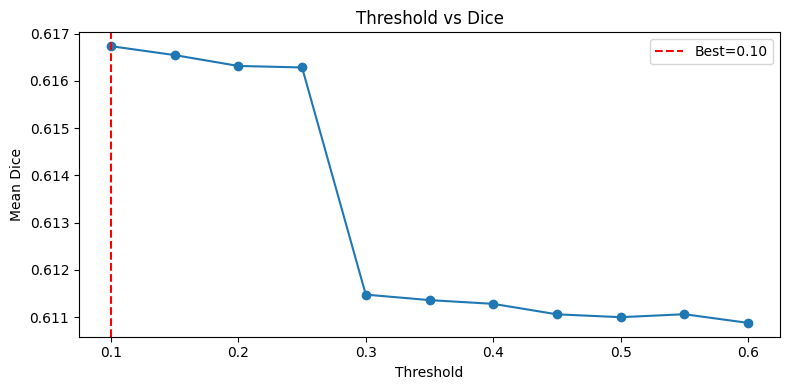

In [11]:
thresholds   = np.arange(0.10, 0.65, 0.05)
thresh_dices = []

model.eval()
with torch.no_grad():
    all_probs, all_gts = [], []
    for imgs, masks in val_loader:
        imgs = imgs.to(DEVICE)
        prob = torch.sigmoid(model(imgs)).cpu().numpy()  # (B,1,H,W)
        all_probs.append(prob[:, 0])
        all_gts.append(masks.numpy()[:, 0])

all_probs = np.concatenate(all_probs, axis=0)   # (N, H, W)
all_gts   = np.concatenate(all_gts,   axis=0)

for t in thresholds:
    preds = (all_probs > t).astype(np.uint8)
    preds = np.array([clean_prediction(p) for p in preds])
    d = np.mean([dice_score(preds[i], all_gts[i]) for i in range(len(preds))])
    thresh_dices.append(d)
    print(f'  t={t:.2f}  Dice={d:.4f}')

BEST_THRESHOLD = thresholds[np.argmax(thresh_dices)]
print(f'\n✓ Best threshold : {BEST_THRESHOLD:.2f}  '
      f'(Dice = {max(thresh_dices):.4f})')

# Plot
plt.figure(figsize=(8, 4))
plt.plot(thresholds, thresh_dices, 'o-')
plt.axvline(BEST_THRESHOLD, color='r', linestyle='--', label=f'Best={BEST_THRESHOLD:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Mean Dice')
plt.title('Threshold vs Dice'); plt.legend(); plt.tight_layout()
plt.show()

## 15. Full Evaluation with Best Threshold

In [12]:
preds_bin = (all_probs > BEST_THRESHOLD).astype(np.uint8)
preds_bin = np.array([clean_prediction(p) for p in preds_bin])

dice_list   = [dice_score(preds_bin[i], all_gts[i]) for i in range(len(preds_bin))]
mean_dice   = np.mean(dice_list)
median_dice = np.median(dice_list)

# Exclude all-empty cases for a 'positive-only' dice
pos_idx  = [i for i in range(len(all_gts)) if all_gts[i].sum() > 0]
pos_dice = np.mean([dice_list[i] for i in pos_idx])

print(f'Mean   Dice  (all)      : {mean_dice:.4f}')
print(f'Median Dice  (all)      : {median_dice:.4f}')
print(f'Mean   Dice  (positives): {pos_dice:.4f}')
print(f'Positive samples        : {len(pos_idx)} / {len(all_gts)}')

Mean   Dice  (all)      : 0.6167
Median Dice  (all)      : 0.8598
Mean   Dice  (positives): 0.6124
Positive samples        : 178 / 180


## 16. Rich Visualization: CT / GT / Pred / Heatmap / Overlay

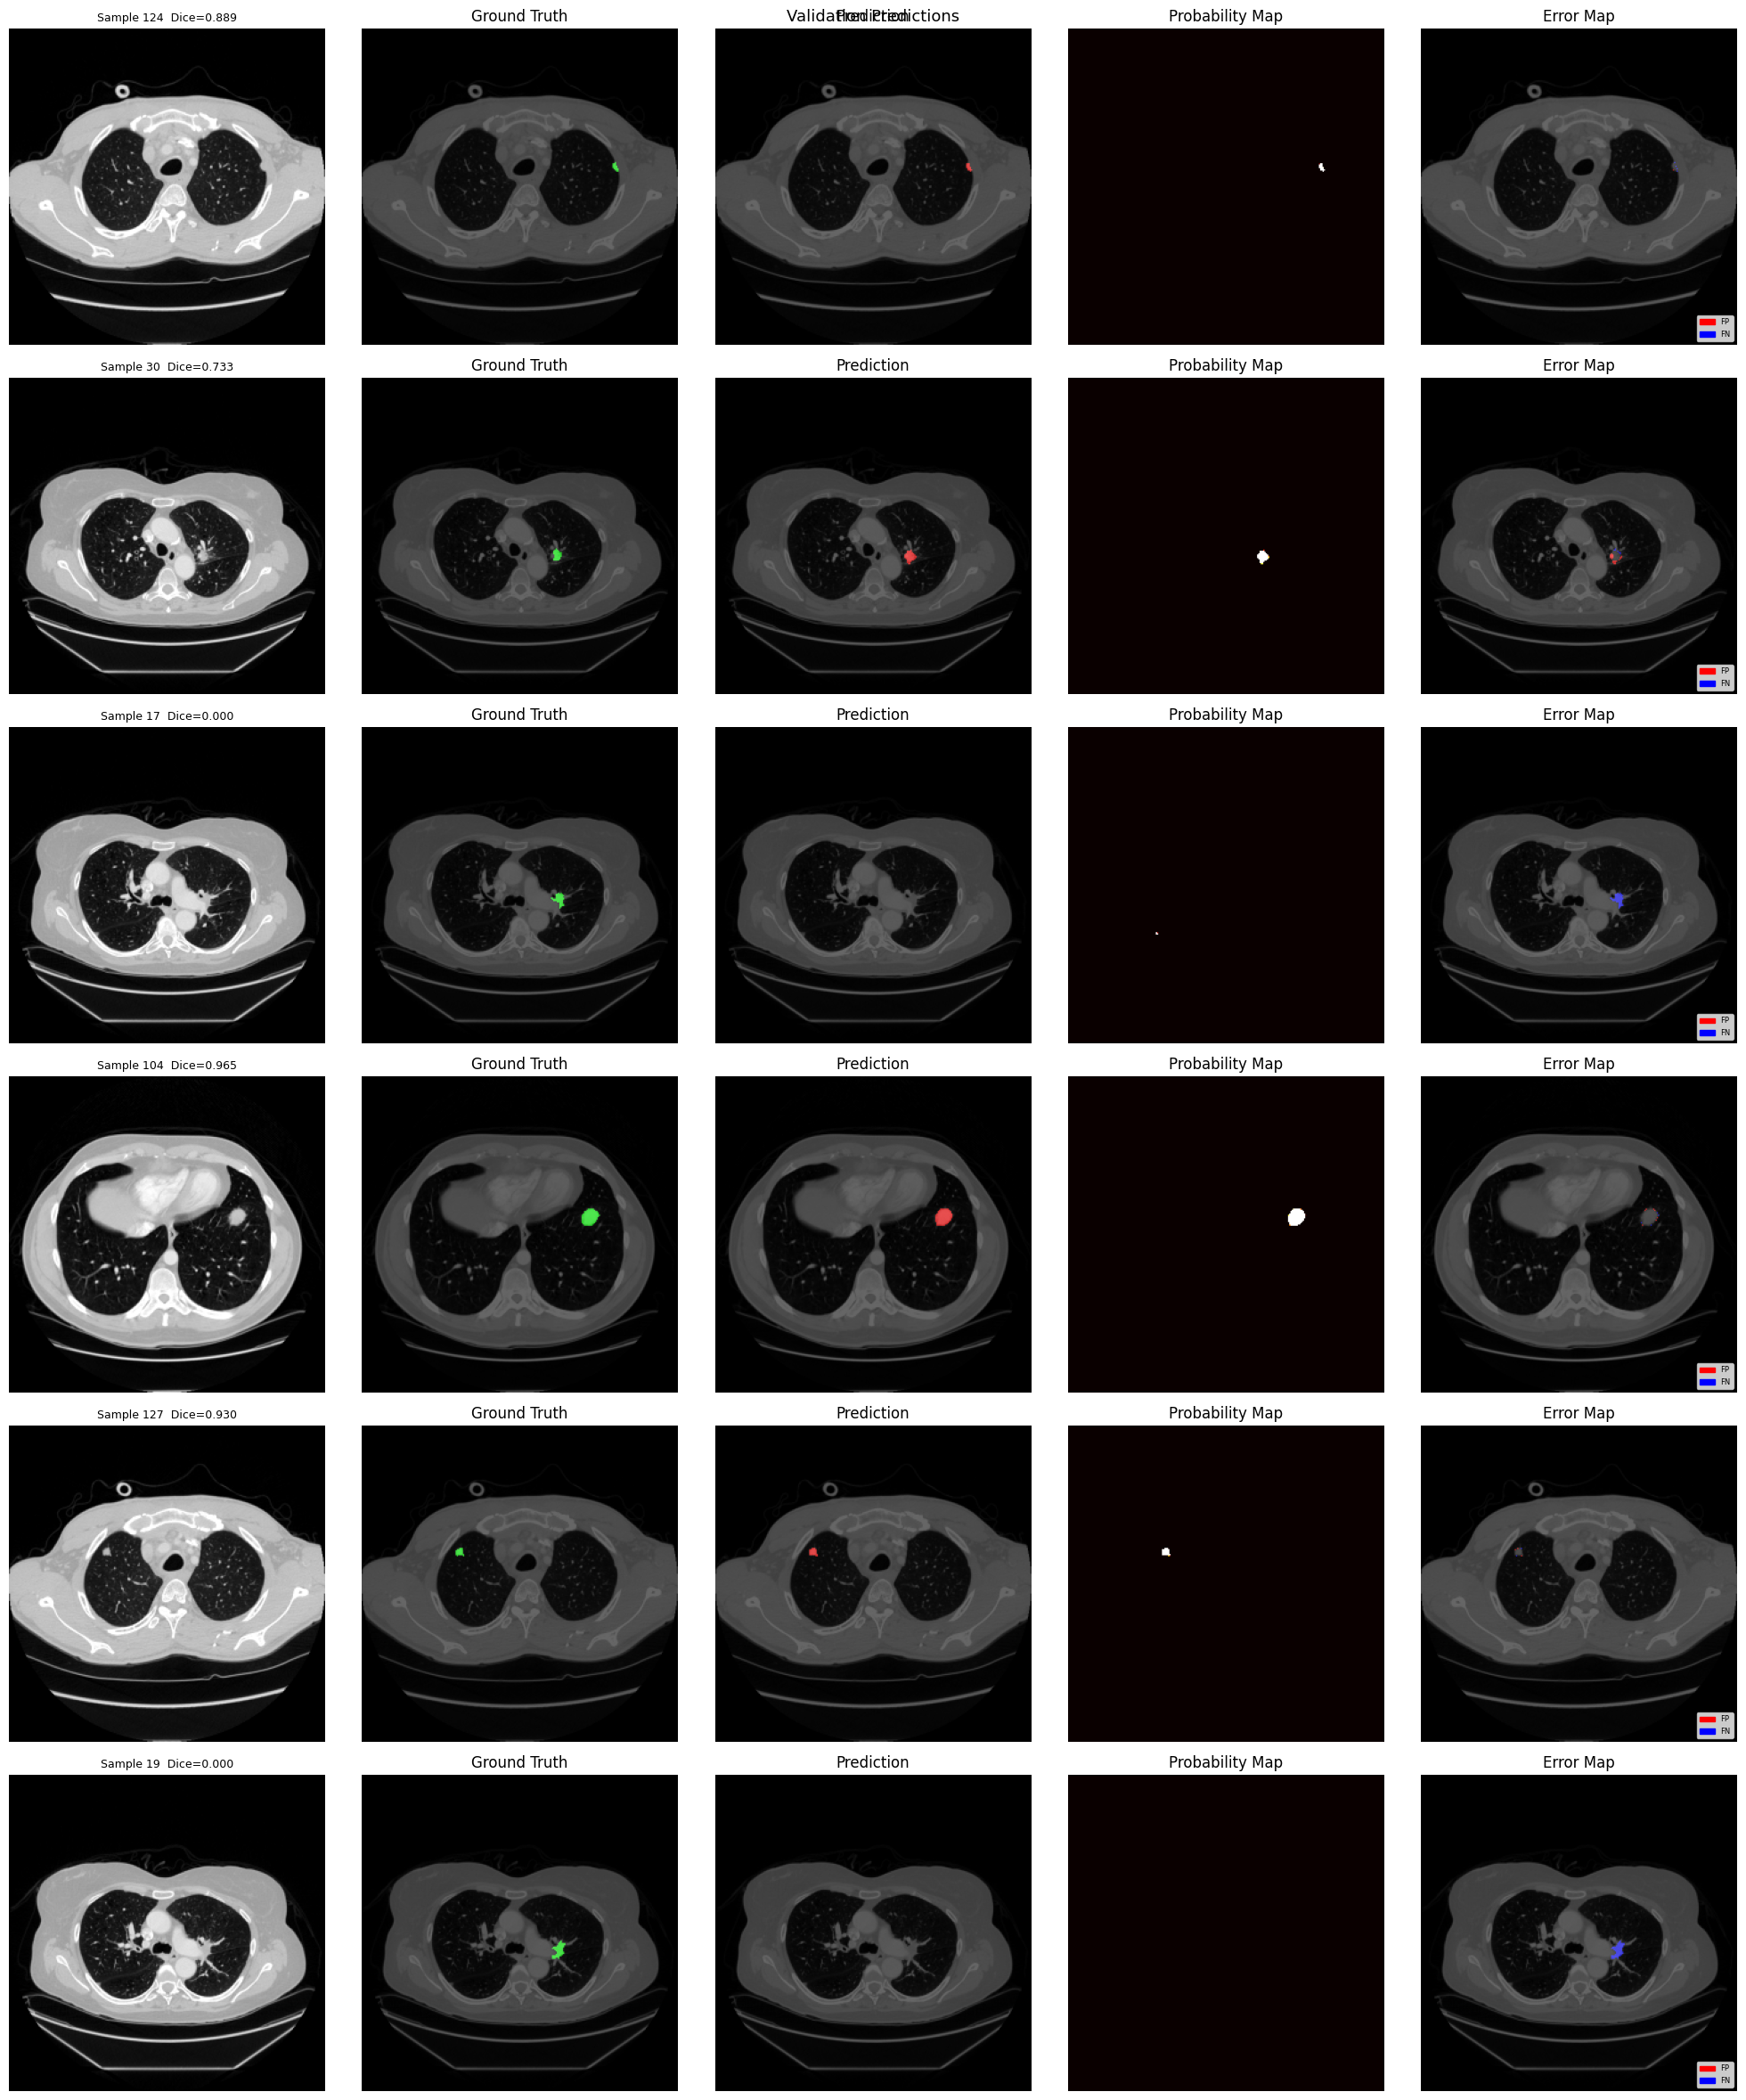

In [13]:
def visualize_sample(ax_row, img_norm, gt, pred_bin, prob_map):
    """Fill a row of 5 axes: CT | GT overlay | Pred overlay | Heatmap | Diff."""
    # Convert to display
    ct = img_norm           # already [0,1]
    gt_overlay = np.zeros((*ct.shape, 3))
    gt_overlay[gt == 1] = [0, 1, 0]

    axes = ax_row
    titles = ['CT Slice', 'Ground Truth', 'Prediction', 'Probability Map', 'Error Map']

    axes[0].imshow(ct,       cmap='gray'); axes[0].set_title(titles[0])

    axes[1].imshow(ct,       cmap='gray')
    axes[1].imshow(gt_overlay, alpha=0.6)
    # axes[1].imshow(np.ma.masked_where(gt == 0, gt), cmap='Greens', alpha=0.5)
    axes[1].set_title(titles[1])

    pred_overlay = np.zeros((*ct.shape, 3))
    pred_overlay[pred_bin == 1] = [1, 0, 0] 

    axes[2].imshow(ct,       cmap='gray')
    axes[2].imshow(pred_overlay, alpha=0.6)
    # axes[2].imshow(np.ma.masked_where(pred_bin == 0, pred_bin), cmap='Reds', alpha=0.5)
    axes[2].set_title(titles[2])

    axes[3].imshow(prob_map, cmap='hot', vmin=0, vmax=1); axes[3].set_title(titles[3])

    # Error: FP=red, FN=blue
    error = np.zeros((*ct.shape, 3), dtype=np.float32)
    error[(pred_bin == 1) & (gt == 0)] = [1, 0, 0]   # FP
    error[(pred_bin == 0) & (gt == 1)] = [0, 0, 1]   # FN
    axes[4].imshow(ct, cmap='gray')
    axes[4].imshow(error, alpha=0.6)
    fp_patch = mpatches.Patch(color='red',  label='FP')
    fn_patch = mpatches.Patch(color='blue', label='FN')
    axes[4].legend(handles=[fp_patch, fn_patch], loc='lower right', fontsize=6)
    axes[4].set_title(titles[4])

    for ax in axes:
        ax.axis('off')


# --- show 6 random positive-prediction samples ---
sample_idx = random.sample(pos_idx, min(6, len(pos_idx)))

fig, axes = plt.subplots(len(sample_idx), 5, figsize=(20, 4 * len(sample_idx)))
if len(sample_idx) == 1:
    axes = [axes]

for row, idx in enumerate(sample_idx):
    img_norm = all_probs[idx]   # placeholder; swap for actual normalized image
    # ── retrieve actual normalized image from dataset ──
    img_t, _ = val_ds[idx]
    img_norm  = img_t[0].numpy()   # channel 0

    visualize_sample(
        axes[row],
        img_norm,
        all_gts[idx],
        preds_bin[idx],
        all_probs[idx]
    )
    d = dice_list[idx]
    axes[row][0].set_title(f'Sample {idx}  Dice={d:.3f}', fontsize=9)

plt.suptitle('Validation Predictions', fontsize=13)
plt.tight_layout()
plt.show()

Image shape : (256, 256)
Image range : 0.0000 – 1.0000
Image mean  : 0.2806


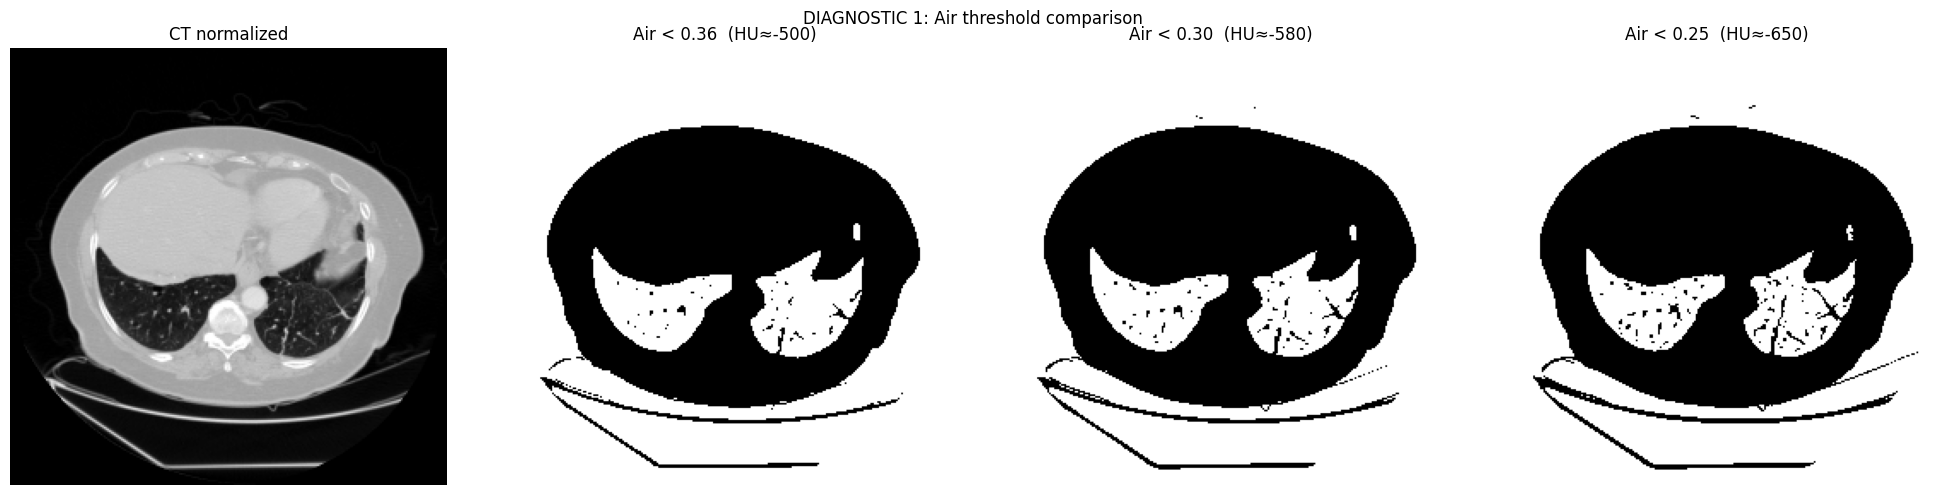


Total air components (incl. background): 5


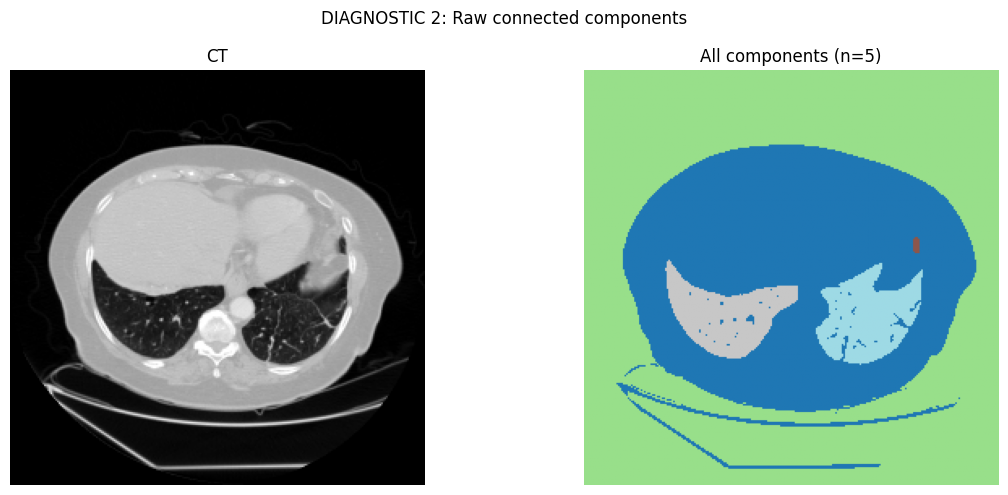

Border-touching component IDs: [1]

Interior components (non-border, non-zero):
  Label   2: area=    37 px  (  0.1%)  bbox=y[103:112] x[203:206]
  Label   3: area=  2410 px  (  3.7%)  bbox=y[117:177] x[50:131]
  Label   4: area=  2503 px  (  3.8%)  bbox=y[119:181] x[143:208]


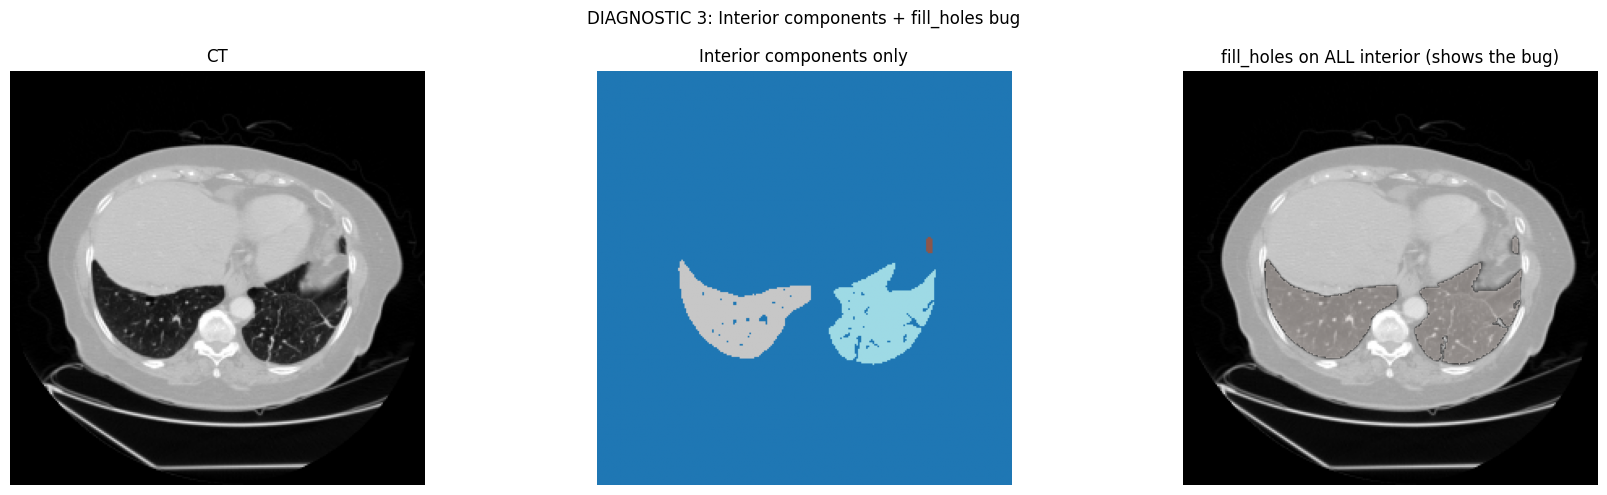


Candidates after size filter: [(2503, 4), (2410, 3)]
  Lobe 4: before fill=2503 px, after fill=2557 px
  Lobe 3: before fill=2410 px, after fill=2458 px


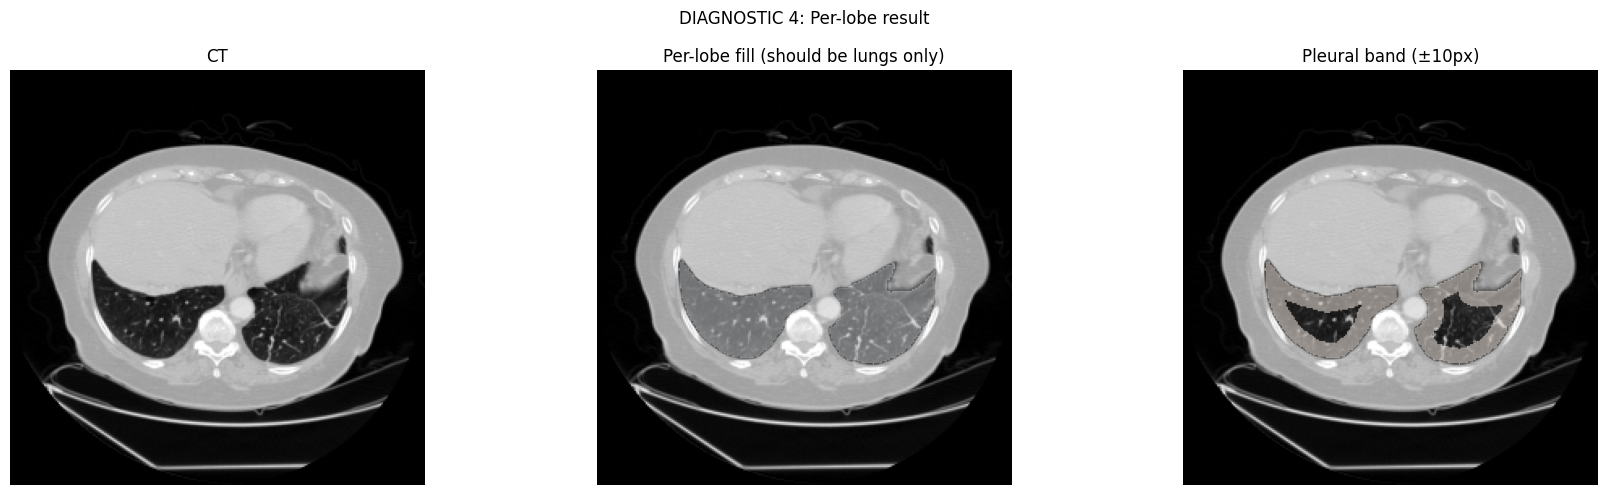


Lung coverage: 7.8%


In [15]:
# ══════════════════════════════════════════════════════════════════
#  DIAGNOSTIC CELL — run this to understand what's happening
#  Paste into a new cell and run BEFORE fixing get_lung_mask
# ══════════════════════════════════════════════════════════════════

import cv2
import numpy as np
from scipy.ndimage import binary_fill_holes, distance_transform_edt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── grab one slice ────────────────────────────────────────────────
_idx = 0
_img_t, _ = val_ds[_idx]
img = _img_t[0].numpy()   # normalized [0,1]

print(f"Image shape : {img.shape}")
print(f"Image range : {img.min():.4f} – {img.max():.4f}")
print(f"Image mean  : {img.mean():.4f}")

# ── 1. what does the air threshold actually capture? ──────────────
air036 = (img < 0.36).astype(np.uint8)
air030 = (img < 0.30).astype(np.uint8)
air025 = (img < 0.25).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img,    cmap='gray');      axes[0].set_title('CT normalized')
axes[1].imshow(air036, cmap='gray');      axes[1].set_title('Air < 0.36  (HU≈-500)')
axes[2].imshow(air030, cmap='gray');      axes[2].set_title('Air < 0.30  (HU≈-580)')
axes[3].imshow(air025, cmap='gray');      axes[3].set_title('Air < 0.25  (HU≈-650)')
for a in axes: a.axis('off')
plt.suptitle('DIAGNOSTIC 1: Air threshold comparison', fontsize=12)
plt.tight_layout(); plt.show()

# ── 2. connected components BEFORE border removal ─────────────────
n_labels, labels = cv2.connectedComponents(air036, connectivity=8)
print(f"\nTotal air components (incl. background): {n_labels}")

# Show label map
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img, cmap='gray');  ax[0].set_title('CT')
ax[1].imshow(labels, cmap='tab20'); ax[1].set_title(f'All components (n={n_labels})')
for a in ax: a.axis('off')
plt.suptitle('DIAGNOSTIC 2: Raw connected components', fontsize=12)
plt.tight_layout(); plt.show()

# ── 3. which components touch the border? ─────────────────────────
H, W = img.shape
border_ids = set()
for edge in [labels[0,:], labels[-1,:], labels[:,0], labels[:,-1]]:
    border_ids.update(np.unique(edge).tolist())
border_ids.discard(0)
print(f"Border-touching component IDs: {sorted(border_ids)}")

# ── 4. what are the remaining interior components? ────────────────
print("\nInterior components (non-border, non-zero):")
for lbl in range(1, n_labels):
    if lbl in border_ids:
        continue
    area = int((labels == lbl).sum())
    pct  = 100 * area / (H * W)
    # bounding box
    ys, xs = np.where(labels == lbl)
    print(f"  Label {lbl:3d}: area={area:6d} px  ({pct:5.1f}%)  "
          f"bbox=y[{ys.min()}:{ys.max()}] x[{xs.min()}:{xs.max()}]")

# ── 5. visualize interior components colored ──────────────────────
interior_map = np.zeros_like(labels)
colors_used  = []
for lbl in range(1, n_labels):
    if lbl not in border_ids:
        interior_map[labels == lbl] = lbl

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img,          cmap='gray');   axes[0].set_title('CT')
axes[1].imshow(interior_map, cmap='tab20');  axes[1].set_title('Interior components only')

# Show what binary_fill_holes does to ALL of them at once (the bug)
all_interior = (interior_map > 0).astype(np.uint8)
filled_all   = binary_fill_holes(all_interior).astype(np.uint8)
axes[2].imshow(img,      cmap='gray')
axes[2].imshow(np.ma.masked_where(filled_all == 0, filled_all.astype(float)),
               cmap='Reds', alpha=0.5)
axes[2].set_title('fill_holes on ALL interior (shows the bug)')
for a in axes: a.axis('off')
plt.suptitle('DIAGNOSTIC 3: Interior components + fill_holes bug', fontsize=12)
plt.tight_layout(); plt.show()

# ── 6. per-lobe fill (the fix — let's verify it works here) ───────
min_px = int(0.01 * H * W)
max_px = int(0.45 * H * W)

candidates = []
for lbl in range(1, n_labels):
    if lbl in border_ids:
        continue
    area = int((labels == lbl).sum())
    if min_px <= area <= max_px:
        candidates.append((area, lbl))

candidates.sort(reverse=True)
print(f"\nCandidates after size filter: {[(a, l) for a,l in candidates]}")
keep_lbls = [lbl for _, lbl in candidates[:2]]

lung_fixed = np.zeros((H, W), dtype=np.uint8)
for lbl in keep_lbls:
    lobe        = (labels == lbl).astype(np.uint8)
    lobe_filled = binary_fill_holes(lobe).astype(np.uint8)
    print(f"  Lobe {lbl}: before fill={lobe.sum()} px, after fill={lobe_filled.sum()} px")
    lung_fixed  = np.maximum(lung_fixed, lobe_filled)

kernel     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
lung_fixed = cv2.morphologyEx(lung_fixed, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img,        cmap='gray'); axes[0].set_title('CT')
axes[1].imshow(img,        cmap='gray')
axes[1].imshow(np.ma.masked_where(lung_fixed == 0, lung_fixed.astype(float)),
               cmap='Blues', alpha=0.4)
axes[1].set_title('Per-lobe fill (should be lungs only)')
dist   = distance_transform_edt(lung_fixed)
pleura = (lung_fixed > 0) & (dist <= 10)
axes[2].imshow(img, cmap='gray')
axes[2].imshow(np.ma.masked_where(pleura == 0, pleura.astype(float)),
               cmap='Oranges', alpha=0.5)
axes[2].set_title('Pleural band (±10px)')
for a in axes: a.axis('off')
plt.suptitle('DIAGNOSTIC 4: Per-lobe result', fontsize=12)
plt.tight_layout(); plt.show()

print(f"\nLung coverage: {lung_fixed.mean()*100:.1f}%")

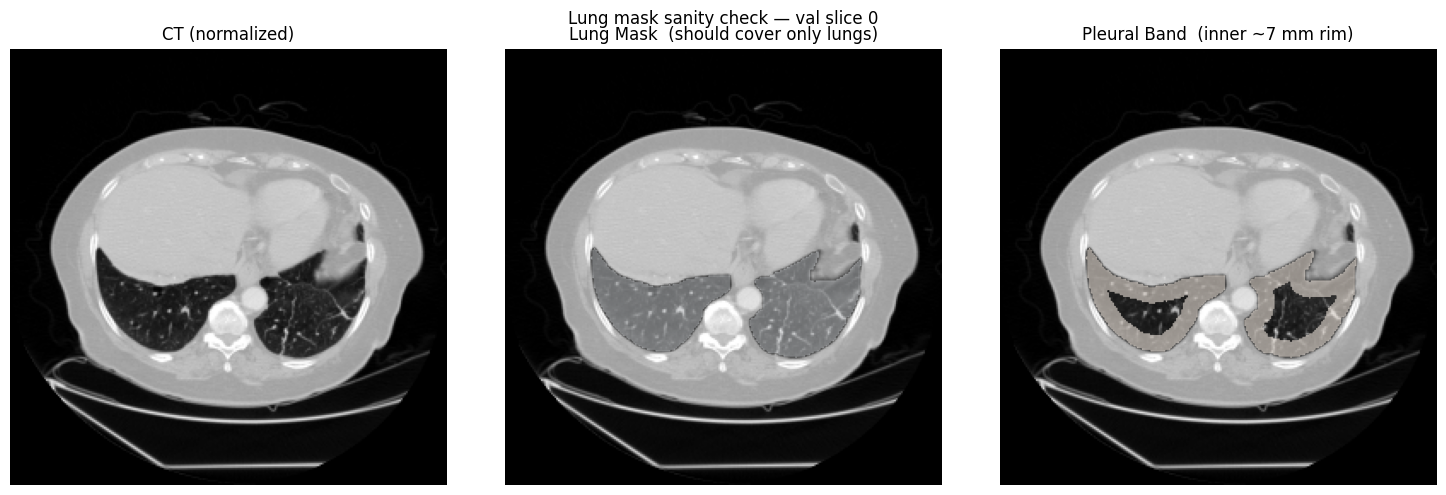

Lung mask coverage: 7.8%  (expected roughly 20–45% for a mid-chest slice)


In [17]:
from scipy.ndimage import distance_transform_edt, binary_fill_holes
def get_lung_mask(img_norm: np.ndarray) -> np.ndarray:
    """
    Robust lung parenchyma segmentation on a NORMALIZED [0,1] CT slice.

    Fixes vs previous version:
    - binary_fill_holes applied PER LOBE (not globally) so mediastinum/heart
      is never included.
    - Two-pass component selection: first remove border-touching background,
      then select only components with realistic lung-lobe size (>1% of image).
    - Closing kernel reduced so we don't bridge the mediastinal gap.
    """
    import cv2
    import numpy as np
    from scipy.ndimage import binary_fill_holes

    H, W = img_norm.shape

    # ── Step 1: air threshold ──────────────────────────────────────────
    # HU -500 in [-1000,400] window → (500/1400) ≈ 0.357
    air = (img_norm < 0.36).astype(np.uint8)

    # ── Step 2: label all connected air components ─────────────────────
    n_labels, labels = cv2.connectedComponents(air, connectivity=8)

    # ── Step 3: find background IDs (touch any image border) ──────────
    border_ids = set()
    for edge in [labels[0, :], labels[-1, :], labels[:, 0], labels[:, -1]]:
        border_ids.update(np.unique(edge).tolist())
    border_ids.discard(0)  # 0 = non-air (tissue), not a component

    # ── Step 4: collect interior candidate lung lobes ──────────────────
    min_lobe_px = int(0.01 * H * W)   # at least 1% of image area
    max_lobe_px = int(0.45 * H * W)   # at most 45% (one lobe won't fill half)

    candidates = []
    for lbl in range(1, n_labels):
        if lbl in border_ids:
            continue
        area = int((labels == lbl).sum())
        if min_lobe_px <= area <= max_lobe_px:
            candidates.append((area, lbl))

    # Keep up to 2 largest (left + right lung)
    candidates.sort(reverse=True)
    keep_lbls = [lbl for _, lbl in candidates[:2]]

    # ── Step 5: fill holes SEPARATELY per lobe ─────────────────────────
    # This prevents filling the mediastinum between the two lungs.
    lung_filled = np.zeros((H, W), dtype=np.uint8)
    for lbl in keep_lbls:
        lobe = (labels == lbl).astype(np.uint8)
        lobe_filled = binary_fill_holes(lobe).astype(np.uint8)
        lung_filled = np.maximum(lung_filled, lobe_filled)

    # ── Step 6: small closing to seal micro-gaps at pleural surface ────
    # Use a smaller kernel (5×5) so left/right lungs are never bridged.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    lung_closed = cv2.morphologyEx(lung_filled, cv2.MORPH_CLOSE, kernel)

    return lung_closed.astype(np.uint8)

def get_pleural_band(lung_mask: np.ndarray,
                     distance_px: int = 10) -> np.ndarray:
    """
    Return the pleural band: lung pixels within `distance_px` of the
    lung boundary (inner surface).

    distance_px=10 at 256×256 resolution ≈ 7 mm with 0.7 mm spacing.
    """
    if lung_mask.sum() == 0:
        return np.zeros_like(lung_mask)
    dist_inside = distance_transform_edt(lung_mask)   # 0 at boundary, increases inward
    pleura = (lung_mask > 0) & (dist_inside <= distance_px)
    return pleura.astype(np.uint8)


def is_juxta_pleural(lung_mask: np.ndarray,
                      nodule_mask: np.ndarray,
                      distance_px: int = 10) -> bool:
    """
    True if any nodule pixel falls within `distance_px` pixels of the
    lung boundary.

    distance_px=10 at 256×256 resolution ≈ 7 mm (clinically, juxta-pleural
    is typically defined as nodule touching or within ~5 mm of pleura).
    """
    if nodule_mask.sum() == 0 or lung_mask.sum() == 0:
        return False
    pleura = get_pleural_band(lung_mask, distance_px)
    return bool(np.logical_and(pleura, nodule_mask > 0).any())


def get_nodule_stats(nodule_mask: np.ndarray,
                      lung_mask: np.ndarray,
                      pixel_spacing_mm: float = 0.7) -> dict | None:
    """
    Return a dict with nodule size, centroid, distance-to-pleura (mm),
    and juxta_pleural flag.
    """
    if nodule_mask.sum() == 0:
        return None

    props = measure.regionprops(nodule_mask.astype(np.uint8))
    if not props:
        return None

    p = max(props, key=lambda r: r.area)   # largest component
    area_px     = p.area
    diameter_mm = np.sqrt(4 * area_px / np.pi) * pixel_spacing_mm
    cy, cx      = int(p.centroid[0]), int(p.centroid[1])

    dist_map = distance_transform_edt(lung_mask)
    dist_mm  = float(dist_map[cy, cx]) * pixel_spacing_mm

    return {
        'area_px':           area_px,
        'diameter_mm':       round(diameter_mm, 2),
        'centroid':          (cy, cx),
        'dist_to_pleura_mm': round(dist_mm, 2),
        'juxta_pleural':     dist_mm < 5.0,
    }


# ── quick sanity check ────────────────────────────────────────────────
# Pick a random val slice and display the lung mask to verify it looks right
_idx = 0
_img_t, _ = val_ds[_idx]
_img_norm  = _img_t[0].numpy()
_lung      = get_lung_mask(_img_norm)
_pleura    = get_pleural_band(_lung, distance_px=10)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(_img_norm, cmap='gray');  ax[0].set_title('CT (normalized)')
ax[1].imshow(_img_norm, cmap='gray')
ax[1].imshow(np.ma.masked_where(_lung == 0, _lung), cmap='Blues', alpha=0.4)
ax[1].set_title('Lung Mask  (should cover only lungs)')
ax[2].imshow(_img_norm, cmap='gray')
ax[2].imshow(np.ma.masked_where(_pleura == 0, _pleura.astype(float)),
             cmap='Oranges', alpha=0.55)
ax[2].set_title('Pleural Band  (inner ~7 mm rim)')
for a in ax:
    a.axis('off')
plt.suptitle(f'Lung mask sanity check — val slice {_idx}', fontsize=12)
plt.tight_layout()
plt.show()

lung_coverage = _lung.mean()
print(f'Lung mask coverage: {lung_coverage*100:.1f}%  '
      f'(expected roughly 20–45% for a mid-chest slice)')

In [18]:
JUXTA_DIST_PX = 10    # ≈7 mm; increase to catch more borderline cases

juxta_gt_count   = 0
juxta_pred_count = 0
nodule_stats     = []

for i in range(len(val_ds)):
    img_t, mask_t = val_ds[i]
    img_norm = img_t[0].numpy()
    gt       = all_gts[i]
    pred     = preds_bin[i]

    lung_mask = get_lung_mask(img_norm)

    if gt.sum() > 0 and is_juxta_pleural(lung_mask, gt, JUXTA_DIST_PX):
        juxta_gt_count += 1

    if pred.sum() > 0 and is_juxta_pleural(lung_mask, pred, JUXTA_DIST_PX):
        juxta_pred_count += 1

    stats = get_nodule_stats(pred, lung_mask)
    if stats:
        stats['sample_idx'] = i
        nodule_stats.append(stats)

print(f'Ground-truth juxta-pleural : {juxta_gt_count}')
print(f'Predicted  juxta-pleural   : {juxta_pred_count}')
print(f'Total predicted nodule samples: {len(nodule_stats)}')

if nodule_stats:
    diameters = [s['diameter_mm'] for s in nodule_stats]
    dists     = [s['dist_to_pleura_mm'] for s in nodule_stats]
    print(f'\nNodule diameter  — mean={np.mean(diameters):.1f} mm  '
          f'median={np.median(diameters):.1f} mm  max={np.max(diameters):.1f} mm')
    print(f'Dist to pleura   — mean={np.mean(dists):.1f} mm  '
          f'median={np.median(dists):.1f} mm')

Ground-truth juxta-pleural : 131
Predicted  juxta-pleural   : 95
Total predicted nodule samples: 130

Nodule diameter  — mean=6.8 mm  median=6.5 mm  max=13.5 mm
Dist to pleura   — mean=5.4 mm  median=4.9 mm


Extracting malignancy labels from all patients...


 55%|█████▌    | 55/100 [01:29<01:12,  1.61s/it]

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.


 92%|█████████▏| 92/100 [02:35<00:15,  1.88s/it]

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.


100%|██████████| 100/100 [02:47<00:00,  1.67s/it]


Total nodule crops      : 292
  Malignant (score ≥ 3): 152
  Benign    (score <  3): 140
  Class balance         : 52.1% malignant


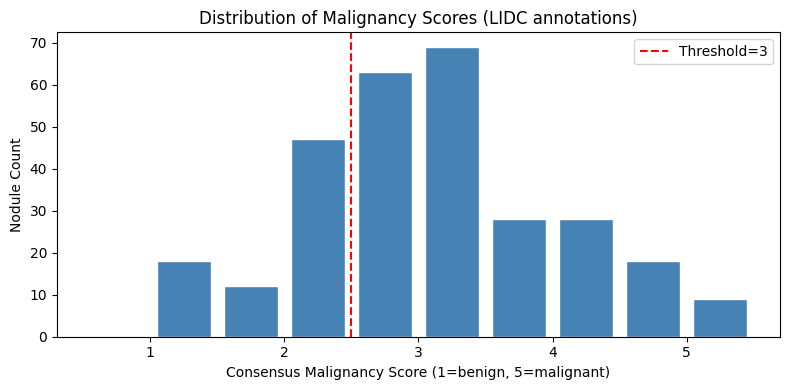


Malignancy train crops : 224
Malignancy val crops   : 68
Malignancy pos_weight  : 0.92

Malignancy classifier params: 11,242,305
[01/30] Train 0.6680 | Val 0.6458 | AUC 0.7254
  ✓ Saved (AUC=0.7254)
[02/30] Train 0.5978 | Val 0.5611 | AUC 0.7158
[03/30] Train 0.5722 | Val 0.4892 | AUC 0.8200
  ✓ Saved (AUC=0.8200)
[04/30] Train 0.5444 | Val 0.5926 | AUC 0.7873
[05/30] Train 0.4672 | Val 0.4921 | AUC 0.8065
[06/30] Train 0.5400 | Val 0.4824 | AUC 0.7942
[07/30] Train 0.4229 | Val 0.8792 | AUC 0.7393
[08/30] Train 0.4649 | Val 0.5902 | AUC 0.8012
[09/30] Train 0.3953 | Val 0.5811 | AUC 0.8012
[10/30] Train 0.3437 | Val 0.7565 | AUC 0.7764
[11/30] Train 0.3741 | Val 0.9233 | AUC 0.7267
[12/30] Train 0.3047 | Val 0.8022 | AUC 0.7367
[13/30] Train 0.3466 | Val 0.5945 | AUC 0.8082
[14/30] Train 0.3026 | Val 0.6110 | AUC 0.8047
[15/30] Train 0.3121 | Val 0.7947 | AUC 0.8025
[16/30] Train 0.2546 | Val 0.6751 | AUC 0.8012
[17/30] Train 0.2165 | Val 0.7146 | AUC 0.7847
[18/30] Train 0.2063 | Va

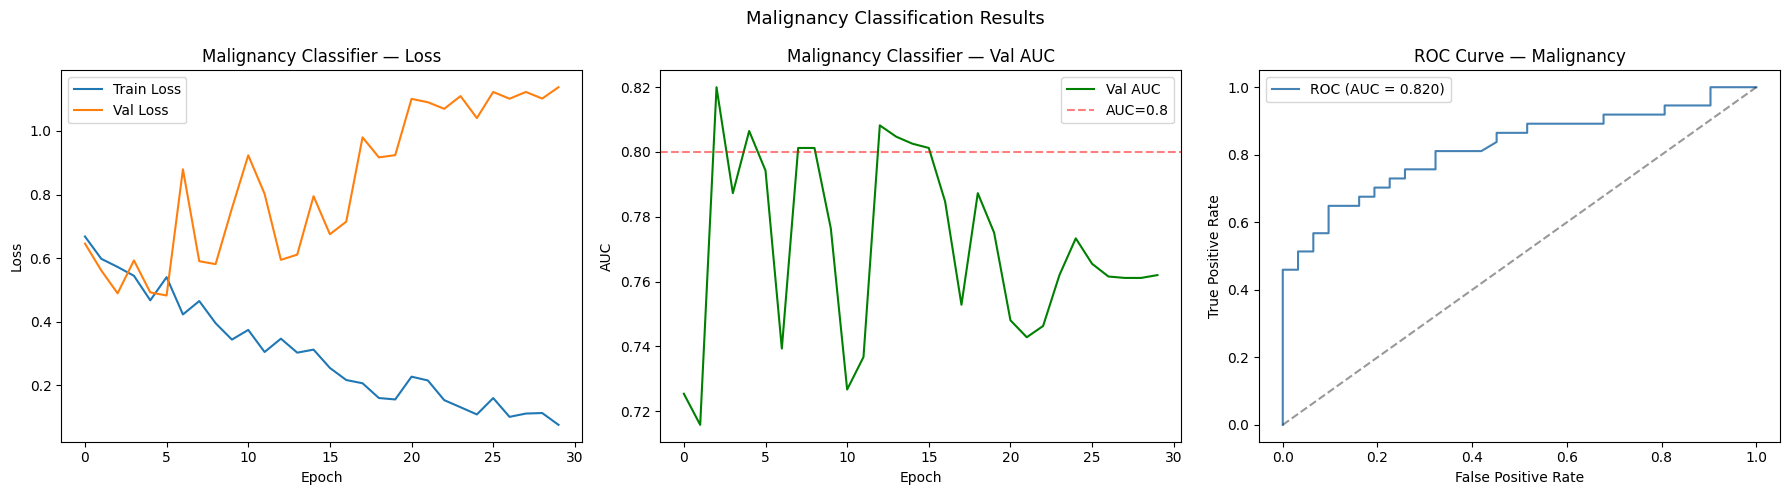


Running combined segmentation + malignancy on sample slices...


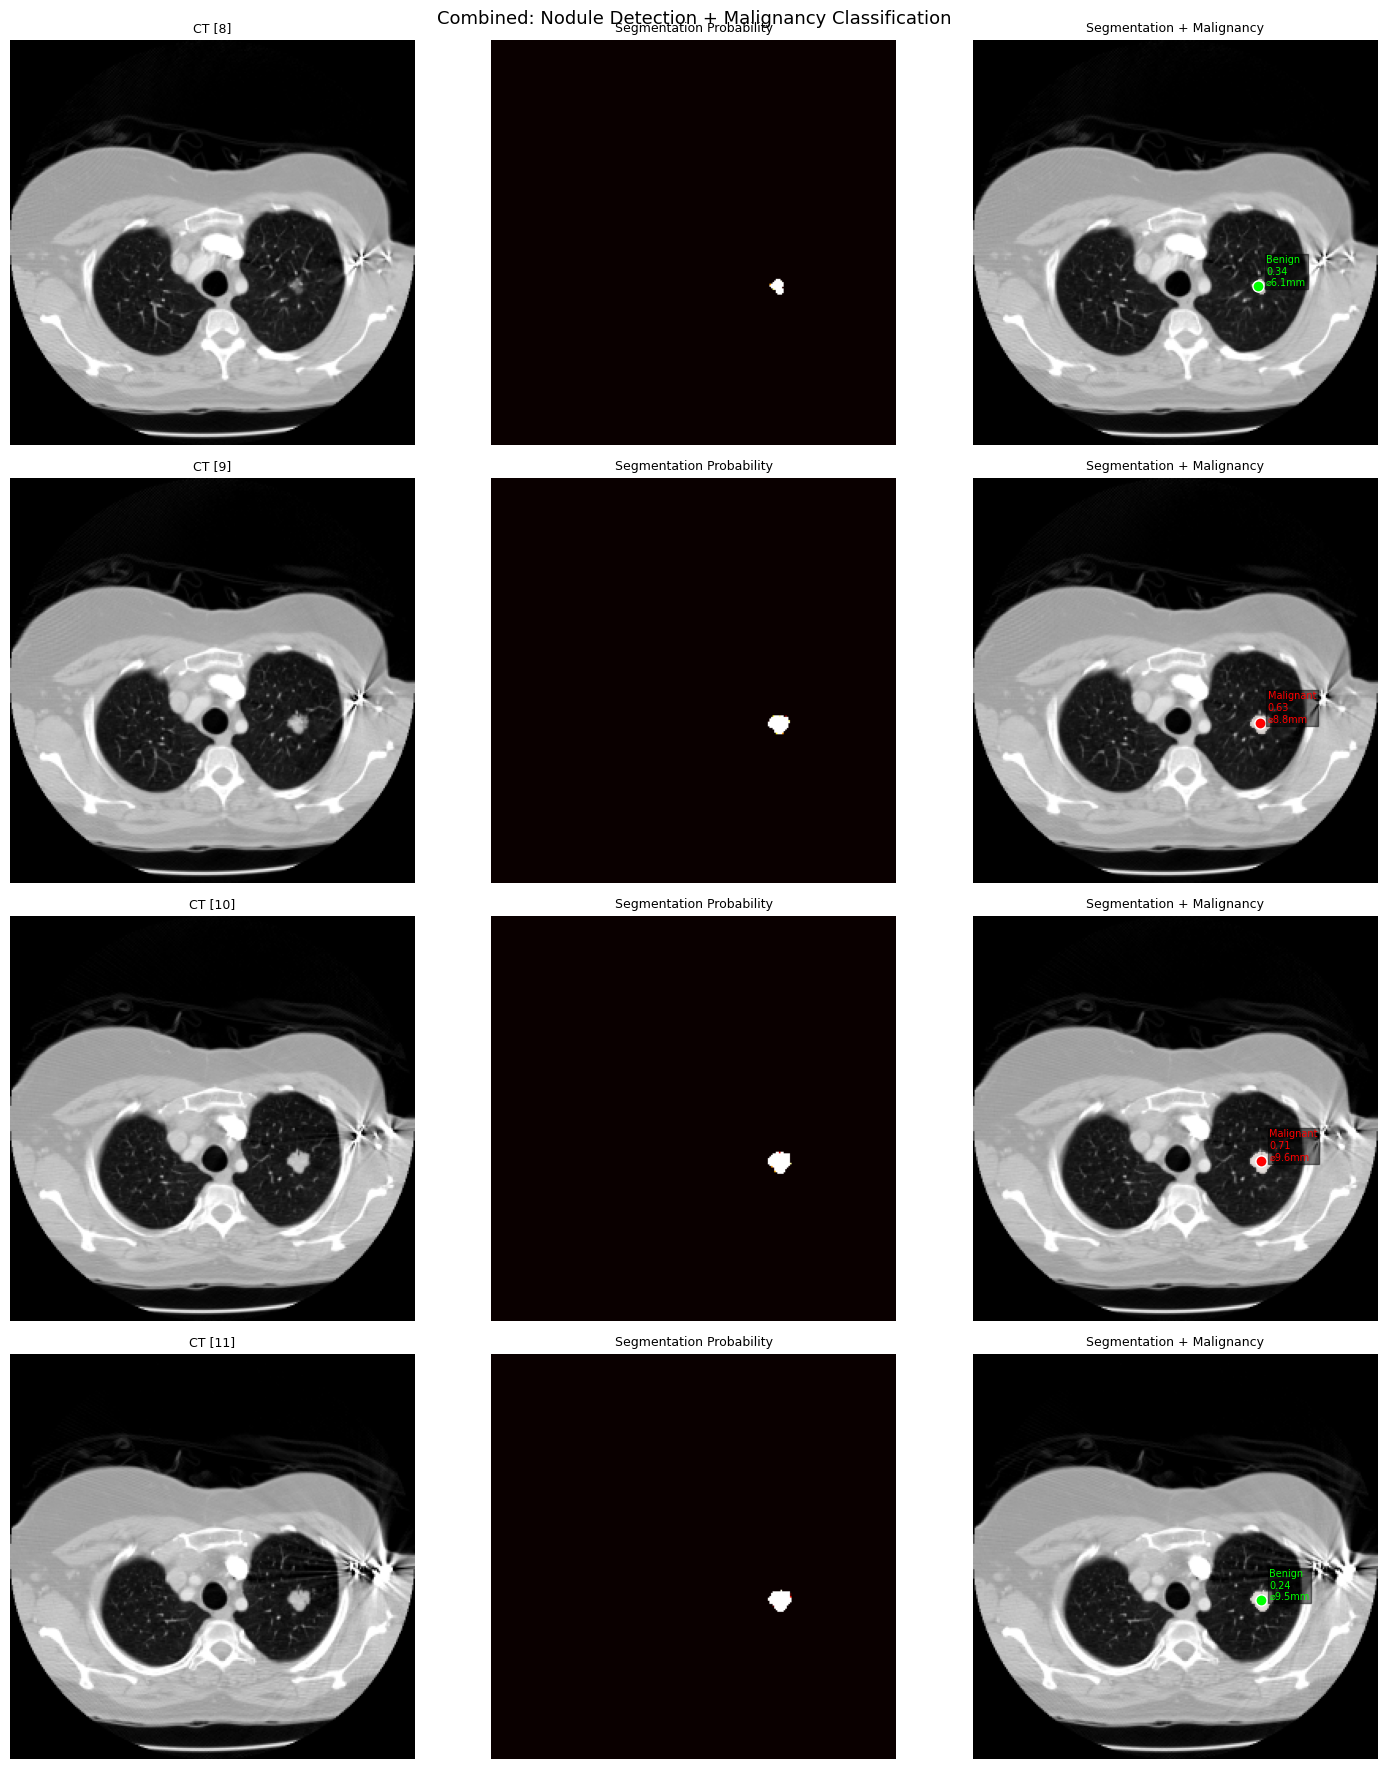


✓ Full pipeline complete.
  Checkpoints saved:
    Segmentation : best_resunet34_v3.pth
    Malignancy   : best_malignancy_classifier.pth


In [19]:
# ══════════════════════════════════════════════════════════════════
#  MALIGNANCY PIPELINE — Add after the segmentation evaluation cells
#
#  LIDC malignancy scale (per radiologist, 1–5):
#    1 = Highly Unlikely malignant
#    2 = Unlikely malignant
#    3 = Indeterminate
#    4 = Suspicious
#    5 = Highly Suspicious
#
#  Strategy:
#  1. Extract per-nodule consensus malignancy score from pylidc
#  2. Binarize: score >= 3 → malignant (common clinical threshold)
#  3. Build a nodule-crop dataset with malignancy labels
#  4. Train a small CNN classifier on top of ResUNet features
#  5. Evaluate with AUC, sensitivity, specificity
# ══════════════════════════════════════════════════════════════════

import pylidc as pl
import pylidc.utils as plu
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, classification_report
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm import tqdm


# ──────────────────────────────────────────────────────────────────
#  STEP 1: Extract malignancy scores for every nodule
# ──────────────────────────────────────────────────────────────────

MALIGNANCY_THRESHOLD = 3   # >= 3 → malignant (indeterminate treated as positive)
NODULE_CROP_SIZE     = 64  # px — crop around nodule centroid for classifier

def get_consensus_malignancy(cluster):
    """
    Average malignancy score across all radiologist annotations in a cluster.
    Returns float (1.0–5.0) or None if no malignancy annotations exist.
    """
    scores = []
    for ann in cluster:
        try:
            scores.append(float(ann.malignancy))
        except Exception:
            continue
    if not scores:
        return None
    return float(np.mean(scores))


def extract_nodule_crops(patient_path, volume, z_positions,
                         crop_size=NODULE_CROP_SIZE):
    """
    For each nodule cluster in a patient, extract:
      - A square crop of the CT centered on the nodule
      - The consensus malignancy label (binary: 0/1)
      - The raw malignancy score

    Returns list of dicts.
    """
    patient_id = os.path.basename(patient_path)
    scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == patient_id).first()
    if scan is None:
        return []

    nodules = scan.cluster_annotations()
    crops   = []
    half    = crop_size // 2

    for cluster in nodules:
        mal_score = get_consensus_malignancy(cluster)
        if mal_score is None:
            continue

        try:
            cmask, cbbox, _ = plu.consensus(cluster, clevel=0.5)
        except Exception:
            continue

        # Nodule centroid in volume space
        z_start = cbbox[2].start
        z_end   = cbbox[2].stop
        z_center= (z_start + z_end) // 2

        y_center = (cbbox[0].start + cbbox[0].stop) // 2
        x_center = (cbbox[1].start + cbbox[1].stop) // 2

        if z_center >= volume.shape[0]:
            continue

        ct_slice = volume[z_center].astype(np.float32)

        # Normalize slice
        ct_norm = np.clip(ct_slice, HU_MIN, HU_MAX)
        ct_norm = (ct_norm - HU_MIN) / (HU_MAX - HU_MIN)

        H, W = ct_norm.shape
        y1 = np.clip(y_center - half, 0, H - crop_size)
        x1 = np.clip(x_center - half, 0, W - crop_size)
        y2 = y1 + crop_size
        x2 = x1 + crop_size

        crop     = ct_norm[y1:y2, x1:x2]
        mask_slc = cmask[:, :, z_center - z_start] if (z_center - z_start) < cmask.shape[2] else None

        # Resize crop to fixed size
        import cv2
        crop = cv2.resize(crop, (crop_size, crop_size))

        crops.append({
            'patient_id':  patient_id,
            'crop':        crop.astype(np.float32),
            'mal_score':   mal_score,
            'mal_label':   int(mal_score >= MALIGNANCY_THRESHOLD),
            'z_center':    z_center,
            'centroid':    (y_center, x_center),
        })

    return crops


# ──────────────────────────────────────────────────────────────────
#  STEP 2: Build the malignancy dataset
# ──────────────────────────────────────────────────────────────────

print('Extracting malignancy labels from all patients...')

mal_data_by_patient = defaultdict(list)
failed_mal = []

for patient_path in tqdm(patients):
    try:
        pid    = os.path.basename(patient_path)
        volume, z_positions = load_ct_volume(patient_path)
        if volume is None:
            continue
        crops = extract_nodule_crops(patient_path, volume, z_positions)
        for c in crops:
            mal_data_by_patient[pid].append(c)
        del volume
    except Exception as e:
        failed_mal.append((patient_path, str(e)))

all_crops = [c for crops in mal_data_by_patient.values() for c in crops]

n_mal  = sum(1 for c in all_crops if c['mal_label'] == 1)
n_ben  = sum(1 for c in all_crops if c['mal_label'] == 0)

print(f'\nTotal nodule crops      : {len(all_crops)}')
print(f'  Malignant (score ≥ {MALIGNANCY_THRESHOLD}): {n_mal}')
print(f'  Benign    (score <  {MALIGNANCY_THRESHOLD}): {n_ben}')
print(f'  Class balance         : {n_mal/(len(all_crops)+1e-6)*100:.1f}% malignant')

# Distribution of raw scores
scores = [c['mal_score'] for c in all_crops]
plt.figure(figsize=(8, 4))
plt.hist(scores, bins=np.arange(0.5, 6.0, 0.5), color='steelblue',
         edgecolor='white', rwidth=0.8)
plt.axvline(MALIGNANCY_THRESHOLD - 0.5, color='red', linestyle='--',
            label=f'Threshold={MALIGNANCY_THRESHOLD}')
plt.xlabel('Consensus Malignancy Score (1=benign, 5=malignant)')
plt.ylabel('Nodule Count')
plt.title('Distribution of Malignancy Scores (LIDC annotations)')
plt.legend()
plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────────────────────────
#  STEP 3: Patient-wise train/val split for malignancy
# ──────────────────────────────────────────────────────────────────

import random
mal_pids = list(mal_data_by_patient.keys())
random.shuffle(mal_pids)
split    = int(0.8 * len(mal_pids))

mal_train_crops = [c for pid in mal_pids[:split]
                   for c in mal_data_by_patient[pid]]
mal_val_crops   = [c for pid in mal_pids[split:]
                   for c in mal_data_by_patient[pid]]

print(f'\nMalignancy train crops : {len(mal_train_crops)}')
print(f'Malignancy val crops   : {len(mal_val_crops)}')


# ──────────────────────────────────────────────────────────────────
#  STEP 4: Malignancy Dataset + DataLoader
# ──────────────────────────────────────────────────────────────────

import albumentations as A

mal_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(0.10, 0.10, p=0.3),
])


class MalignancyDataset(Dataset):
    def __init__(self, crops, augment=False):
        self.crops   = crops
        self.augment = augment

    def __len__(self):
        return len(self.crops)

    def __getitem__(self, idx):
        c    = self.crops[idx]
        img  = c['crop'].copy()          # (H, W) float32 in [0,1]
        label= c['mal_label']

        if self.augment:
            img_u8 = (img * 255).astype(np.uint8)
            out    = mal_aug(image=img_u8)
            img    = out['image'].astype(np.float32) / 255.0

        # 3-channel for pretrained backbone
        img = np.stack([img, img, img], axis=0)

        return (
            torch.tensor(img,   dtype=torch.float32),
            torch.tensor(label, dtype=torch.float32),
        )


# Compute pos_weight to handle class imbalance
pos_weight_mal = torch.tensor([n_ben / (n_mal + 1e-6)]).to(DEVICE)
print(f'Malignancy pos_weight  : {pos_weight_mal.item():.2f}')

mal_train_ds = MalignancyDataset(mal_train_crops, augment=True)
mal_val_ds   = MalignancyDataset(mal_val_crops,   augment=False)

mal_train_loader = DataLoader(mal_train_ds, batch_size=16,
                              shuffle=True,  num_workers=2, pin_memory=True)
mal_val_loader   = DataLoader(mal_val_ds,   batch_size=16,
                              shuffle=False, num_workers=2, pin_memory=True)


# ──────────────────────────────────────────────────────────────────
#  STEP 5: Malignancy Classifier
#  Uses ResNet18 encoder (lightweight, fast to train on small dataset)
# ──────────────────────────────────────────────────────────────────

import torchvision.models as tv_models
from torchvision.models import ResNet18_Weights

class MalignancyClassifier(nn.Module):
    """
    Lightweight ResNet18 classifier for nodule malignancy.
    Input: (B, 3, 64, 64) normalized nodule crop
    Output: (B, 1) logit
    """
    def __init__(self, pretrained=True, dropout=0.4):
        super().__init__()
        backbone = tv_models.resnet18(
            weights=ResNet18_Weights.DEFAULT if pretrained else None
        )
        # Replace final FC
        in_features = backbone.fc.in_features
        backbone.fc  = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
        self.net = backbone

    def forward(self, x):
        return self.net(x).squeeze(1)   # (B,)


mal_model     = MalignancyClassifier(pretrained=True).to(DEVICE)
mal_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_mal)
mal_optimizer = torch.optim.AdamW(mal_model.parameters(), lr=3e-4, weight_decay=1e-3)
mal_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(mal_optimizer, T_max=30)
mal_scaler    = torch.amp.GradScaler('cuda')

MAL_CKPT  = 'best_malignancy_classifier.pth'
MAL_EPOCHS= 30

print(f'\nMalignancy classifier params: '
      f'{sum(p.numel() for p in mal_model.parameters() if p.requires_grad):,}')


# ──────────────────────────────────────────────────────────────────
#  STEP 6: Training loop
# ──────────────────────────────────────────────────────────────────

mal_history  = {'train_loss': [], 'val_loss': [], 'val_auc': []}
best_val_auc = 0.0

for epoch in range(1, MAL_EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────
    mal_model.train()
    t_loss = 0.0
    for imgs, labels in mal_train_loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        mal_optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            logits = mal_model(imgs)
            loss   = mal_criterion(logits, labels)
        mal_scaler.scale(loss).backward()
        mal_scaler.unscale_(mal_optimizer)
        nn.utils.clip_grad_norm_(mal_model.parameters(), 1.0)
        mal_scaler.step(mal_optimizer)
        mal_scaler.update()
        t_loss += loss.item()
    t_loss /= len(mal_train_loader)

    # ── Validate ───────────────────────────────────────────────────
    mal_model.eval()
    v_loss   = 0.0
    all_logits, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in mal_val_loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.amp.autocast('cuda'):
                logits = mal_model(imgs)
                v_loss += mal_criterion(logits, labels).item()
            all_logits.extend(torch.sigmoid(logits).cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    v_loss /= len(mal_val_loader)

    # AUC (only meaningful if both classes present in val)
    try:
        val_auc = roc_auc_score(all_labels, all_logits)
    except ValueError:
        val_auc = 0.0

    mal_scheduler.step()
    mal_history['train_loss'].append(t_loss)
    mal_history['val_loss'].append(v_loss)
    mal_history['val_auc'].append(val_auc)

    print(f'[{epoch:02d}/{MAL_EPOCHS}] '
          f'Train {t_loss:.4f} | Val {v_loss:.4f} | AUC {val_auc:.4f}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            'epoch':       epoch,
            'model_state': mal_model.state_dict(),
            'val_auc':     best_val_auc,
        }, MAL_CKPT)
        print(f'  ✓ Saved (AUC={best_val_auc:.4f})')

print(f'\nBest validation AUC: {best_val_auc:.4f}')


# ──────────────────────────────────────────────────────────────────
#  STEP 7: Load best and full evaluation
# ──────────────────────────────────────────────────────────────────

ckpt = torch.load(MAL_CKPT, map_location=DEVICE)
mal_model.load_state_dict(ckpt['model_state'])
mal_model.eval()

all_probs_mal, all_labels_mal, all_pids_mal = [], [], []
with torch.no_grad():
    for imgs, labels in mal_val_loader:
        imgs = imgs.to(DEVICE)
        with torch.amp.autocast('cuda'):
            logits = mal_model(imgs)
        all_probs_mal.extend(torch.sigmoid(logits).cpu().numpy().tolist())
        all_labels_mal.extend(labels.numpy().tolist())

all_probs_mal  = np.array(all_probs_mal)
all_labels_mal = np.array(all_labels_mal, dtype=int)
all_preds_mal  = (all_probs_mal >= 0.5).astype(int)

final_auc = roc_auc_score(all_labels_mal, all_probs_mal)
print(f'\nFinal AUC : {final_auc:.4f}')
print('\nClassification Report:')
print(classification_report(
    all_labels_mal, all_preds_mal,
    target_names=['Benign', 'Malignant']
))


# ──────────────────────────────────────────────────────────────────
#  STEP 8: ROC Curve + Training curves
# ──────────────────────────────────────────────────────────────────

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(all_labels_mal, all_probs_mal)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(mal_history['train_loss'], label='Train Loss')
axes[0].plot(mal_history['val_loss'],   label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Malignancy Classifier — Loss')
axes[0].legend()

# AUC curve
axes[1].plot(mal_history['val_auc'], color='green', label='Val AUC')
axes[1].axhline(0.8, color='red', linestyle='--', alpha=0.5, label='AUC=0.8')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].set_title('Malignancy Classifier — Val AUC')
axes[1].legend()

# ROC curve
axes[2].plot(fpr, tpr, color='steelblue',
             label=f'ROC (AUC = {final_auc:.3f})')
axes[2].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve — Malignancy')
axes[2].legend()

plt.suptitle('Malignancy Classification Results', fontsize=13)
plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────────────────────────
#  STEP 9: Combined inference — segmentation + malignancy on one slice
# ──────────────────────────────────────────────────────────────────

def analyze_slice(img_hu: np.ndarray,
                  seg_model,
                  mal_model,
                  seg_threshold=BEST_THRESHOLD,
                  crop_size=NODULE_CROP_SIZE):
    """
    Full pipeline on a single raw HU slice:
      1. Segment nodule with ResUNet
      2. For each detected nodule component, classify malignancy
      3. Return prediction mask + per-nodule analysis dict
    """
    import cv2

    seg_model.eval()
    mal_model.eval()

    # ── Preprocess ──────────────────────────────────────────────
    img_norm = np.clip(img_hu, HU_MIN, HU_MAX)
    img_norm = (img_norm - HU_MIN) / (HU_MAX - HU_MIN)
    img_resized = cv2.resize(img_norm, (IMG_SIZE, IMG_SIZE))

    img_t = torch.tensor(
        np.stack([img_resized]*3, axis=0)[None],
        dtype=torch.float32
    ).to(DEVICE)

    # ── Segmentation ────────────────────────────────────────────
    with torch.no_grad():
        logit = seg_model(img_t)
    prob_map = torch.sigmoid(logit).cpu().numpy()[0, 0]
    pred_bin = clean_prediction((prob_map > seg_threshold).astype(np.uint8))

    # ── Per-nodule malignancy ────────────────────────────────────
    n_comp, comp_labels, stats, _ = cv2.connectedComponentsWithStats(
        pred_bin.astype(np.uint8), connectivity=8
    )

    nodule_results = []
    half = crop_size // 2

    for comp_id in range(1, n_comp):
        area = stats[comp_id, cv2.CC_STAT_AREA]
        if area < 20:
            continue

        # Centroid
        ys, xs = np.where(comp_labels == comp_id)
        cy, cx = int(ys.mean()), int(xs.mean())

        # Crop from normalized resized image
        y1 = np.clip(cy - half, 0, IMG_SIZE - crop_size)
        x1 = np.clip(cx - half, 0, IMG_SIZE - crop_size)
        crop = img_resized[y1:y1+crop_size, x1:x1+crop_size]
        crop = cv2.resize(crop, (crop_size, crop_size))

        crop_t = torch.tensor(
            np.stack([crop]*3, axis=0)[None],
            dtype=torch.float32
        ).to(DEVICE)

        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                mal_logit = mal_model(crop_t)
        mal_prob = float(torch.sigmoid(mal_logit).cpu().item())

        nodule_results.append({
            'centroid':       (cy, cx),
            'area_px':        area,
            'diameter_mm':    round(np.sqrt(4*area/np.pi) * 0.7, 1),
            'mal_prob':       round(mal_prob, 3),
            'mal_pred':       'Malignant' if mal_prob >= 0.5 else 'Benign',
        })

    return pred_bin, prob_map, nodule_results


# ── Demo on a few val slices ──────────────────────────────────────
print('\nRunning combined segmentation + malignancy on sample slices...')

demo_indices = [i for i in range(len(val_ds)) if all_gts[i].sum() > 50][:4]

fig, axes = plt.subplots(len(demo_indices), 3,
                          figsize=(15, 4.5 * len(demo_indices)))
if len(demo_indices) == 1:
    axes = [axes]

for row, idx in enumerate(demo_indices):
    img_t, _ = val_ds[idx]
    img_norm  = img_t[0].numpy()

    # Convert back to pseudo-HU for analyze_slice
    img_hu    = img_norm * (HU_MAX - HU_MIN) + HU_MIN

    pred_bin, prob_map, nodules = analyze_slice(img_hu, model, mal_model)

    axes[row][0].imshow(img_norm, cmap='gray')
    axes[row][0].set_title(f'CT [{idx}]', fontsize=9)

    axes[row][1].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
    axes[row][1].set_title('Segmentation Probability', fontsize=9)

    axes[row][2].imshow(img_norm, cmap='gray')
    axes[row][2].imshow(
        np.ma.masked_where(pred_bin == 0, pred_bin.astype(float)),
        cmap='Reds', alpha=0.6)

    for n in nodules:
        cy, cx = n['centroid']
        color  = 'red' if n['mal_pred'] == 'Malignant' else 'lime'
        axes[row][2].plot(cx, cy, 'o', color=color, markersize=8,
                          markeredgecolor='white', markeredgewidth=1)
        axes[row][2].text(
            cx + 5, cy,
            f"{n['mal_pred']}\n{n['mal_prob']:.2f}\n⌀{n['diameter_mm']}mm",
            color=color, fontsize=7,
            bbox=dict(facecolor='black', alpha=0.5, pad=1)
        )

    axes[row][2].set_title('Segmentation + Malignancy', fontsize=9)
    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('Combined: Nodule Detection + Malignancy Classification',
             fontsize=13)
plt.tight_layout()
plt.show()

print('\n✓ Full pipeline complete.')
print('  Checkpoints saved:')
print(f'    Segmentation : {CKPT_PATH}')
print(f'    Malignancy   : {MAL_CKPT}')

Scanning validation set for GT juxta-pleural nodules...
GT-confirmed juxta-pleural slices : 100
  Detected (Dice ≥ 0.10) : 89
  Missed   (Dice <  0.10): 11
  Dice — mean=0.780  median=0.894  max=0.981

Displaying 6 juxta-pleural cases...


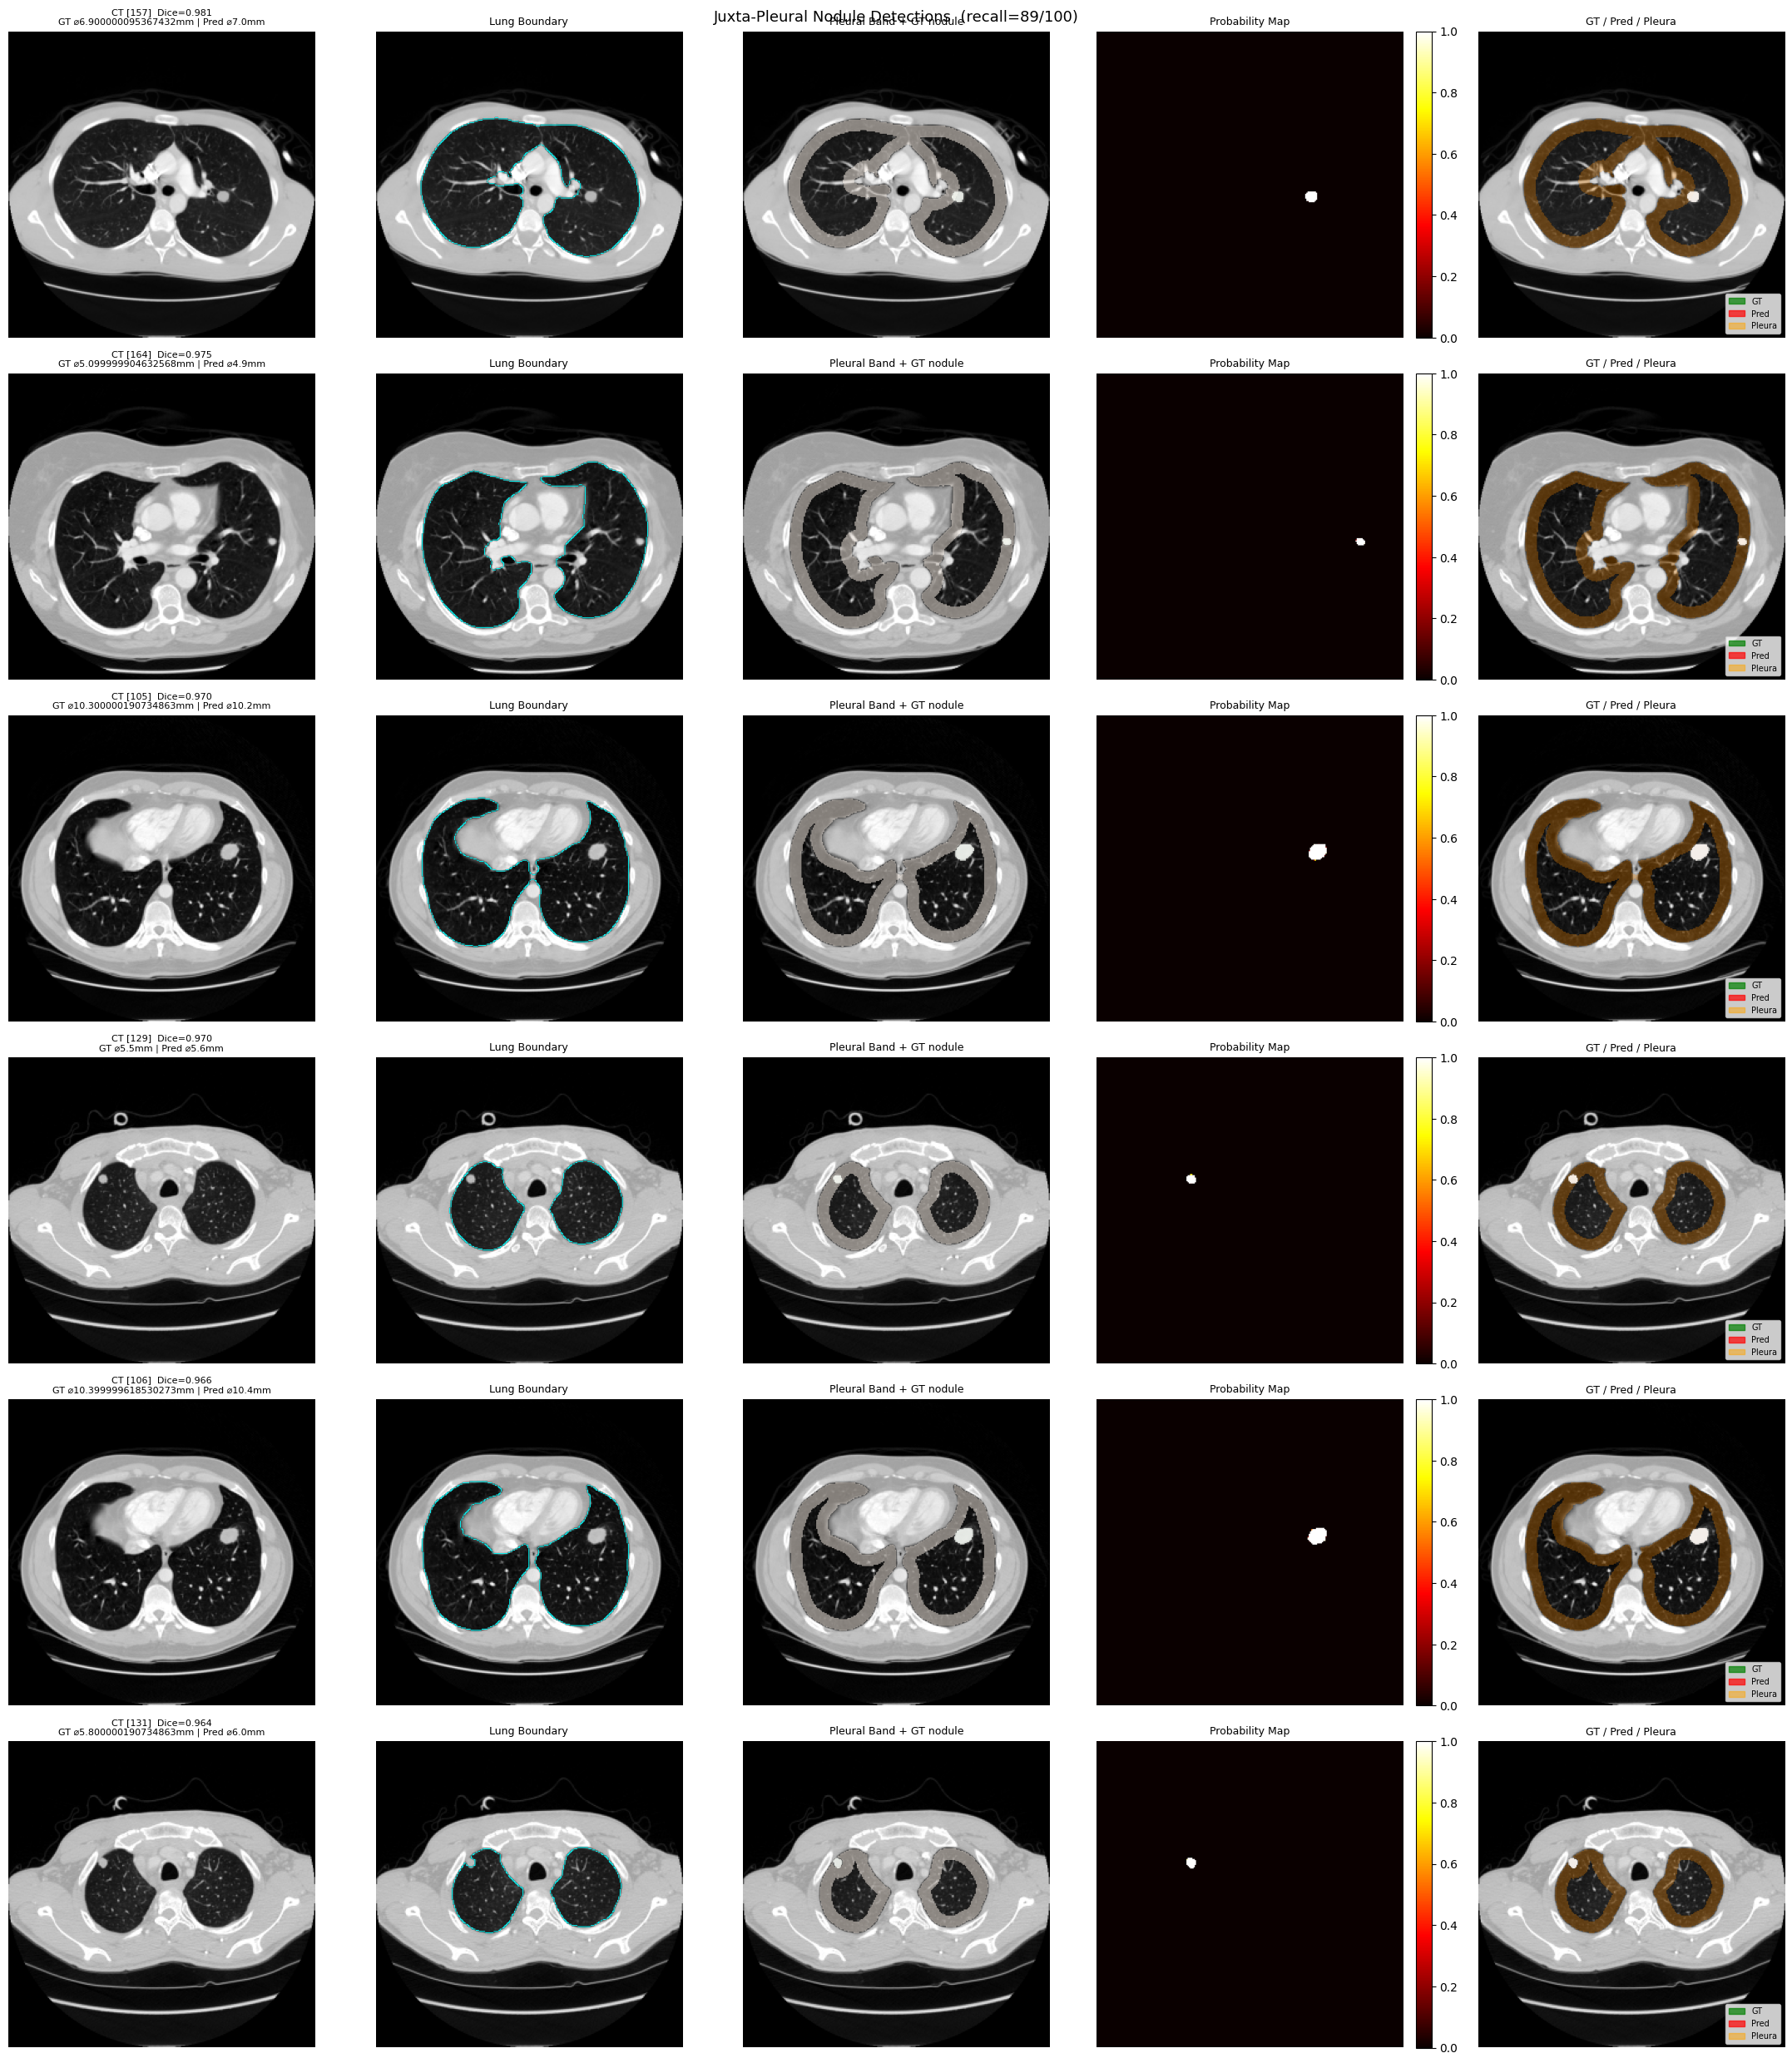


  JUXTA-PLEURAL SUMMARY
  Total GT juxta-pleural slices : 100
  Detected (Dice ≥ 0.10)        : 89
  Missed                         : 11
  Juxta-pleural recall          : 89.0%
  Mean Dice (detected only)     : 0.8765


In [21]:
# ══════════════════════════════════════════════════════════════════
#  REPLACEMENT CELL 19 — Ground-truth driven juxta-pleural finder
#
#  Key insight from diagnostics:
#  - Model IS detecting nodules well (Dice 0.91-0.92)
#  - Lung mask sometimes misses upper lobes on certain slice positions
#  - Instead of relying solely on get_lung_mask for filtering,
#    we use the GROUND TRUTH mask to find confirmed juxta-pleural
#    cases, then show both GT and prediction side by side.
# ══════════════════════════════════════════════════════════════════

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import distance_transform_edt, binary_fill_holes

JUXTA_DIST_PX = 10
MIN_NODULE_PX = 30


def get_lung_mask_v3(img_norm: np.ndarray) -> np.ndarray:
    """
    Improved lung mask that works on all slice positions
    (upper, mid, lower chest) by using multiple thresholds
    and keeping ALL interior air components above min size,
    not just the top 2.
    """
    H, W = img_norm.shape

    # Use the threshold that showed cleanest separation in diagnostics
    air = (img_norm < 0.36).astype(np.uint8)

    # Remove border-connected background
    n_labels, labels = cv2.connectedComponents(air, connectivity=8)
    border_ids = set()
    for edge in [labels[0,:], labels[-1,:], labels[:,0], labels[:,-1]]:
        border_ids.update(np.unique(edge).tolist())
    border_ids.discard(0)

    # Keep ALL interior components larger than 0.5% of image
    # (not just top 2 — upper slices may have 3+ lobe sections)
    min_px = int(0.005 * H * W)
    max_px = int(0.48  * H * W)

    lung_filled = np.zeros((H, W), dtype=np.uint8)
    for lbl in range(1, n_labels):
        if lbl in border_ids:
            continue
        area = int((labels == lbl).sum())
        if min_px <= area <= max_px:
            lobe = (labels == lbl).astype(np.uint8)
            lung_filled = np.maximum(lung_filled,
                                     binary_fill_holes(lobe).astype(np.uint8))

    # Light closing only
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    return cv2.morphologyEx(lung_filled, cv2.MORPH_CLOSE, k).astype(np.uint8)


def is_juxta_pleural_v2(lung_mask, nodule_mask, dist_px=JUXTA_DIST_PX):
    if nodule_mask.sum() == 0 or lung_mask.sum() == 0:
        return False, None
    dist_inside = distance_transform_edt(lung_mask)
    pleura      = (lung_mask > 0) & (dist_inside <= dist_px)
    touching    = np.logical_and(pleura, nodule_mask > 0)
    return bool(touching.any()), pleura.astype(np.uint8)


# ── STEP 1: Find all GT-confirmed juxta-pleural slices ────────────
print('Scanning validation set for GT juxta-pleural nodules...')

confirmed_juxta = []   # (idx, dice, lung_mask, pleura_band)

for i in range(len(val_ds)):
    gt   = all_gts[i]
    pred = preds_bin[i]

    if gt.sum() < MIN_NODULE_PX:       # skip empty / tiny GT
        continue

    img_norm  = val_ds[i][0][0].numpy()
    lung_mask = get_lung_mask_v3(img_norm)

    is_jp, pleura = is_juxta_pleural_v2(lung_mask, gt, JUXTA_DIST_PX)

    if is_jp:
        confirmed_juxta.append({
            'idx':       i,
            'dice':      dice_list[i],
            'lung':      lung_mask,
            'pleura':    pleura,
            'pred_area': int(pred.sum()),
            'gt_area':   int(gt.sum()),
        })

print(f'GT-confirmed juxta-pleural slices : {len(confirmed_juxta)}')

# Sort by Dice descending so we see the best detections first
confirmed_juxta.sort(key=lambda x: -x['dice'])

# Show top results (highest Dice = model detected them well)
detected   = [s for s in confirmed_juxta if s['dice'] >= 0.1]
missed     = [s for s in confirmed_juxta if s['dice'] <  0.1]
print(f'  Detected (Dice ≥ 0.10) : {len(detected)}')
print(f'  Missed   (Dice <  0.10): {len(missed)}')
if confirmed_juxta:
    dices = [s['dice'] for s in confirmed_juxta]
    print(f'  Dice — mean={np.mean(dices):.3f}  '
          f'median={np.median(dices):.3f}  max={np.max(dices):.3f}')

# ── STEP 2: Visualize top detected juxta-pleural cases ────────────
show_list = detected[:6]   # up to 6 best-detected cases

if not show_list:
    print('\nNo detected juxta-pleural cases — showing missed cases instead.')
    show_list = missed[:6]

if not show_list:
    print('No juxta-pleural cases found at all. '
          'Try increasing JUXTA_DIST_PX or lowering MIN_NODULE_PX.')
else:
    print(f'\nDisplaying {len(show_list)} juxta-pleural cases...')
    fig, axes = plt.subplots(len(show_list), 5,
                             figsize=(22, 4.2 * len(show_list)))
    if len(show_list) == 1:
        axes = [axes]

    for row, s in enumerate(show_list):
        idx      = s['idx']
        img_t, gt_t = val_ds[idx]
        img_norm = img_t[0].numpy()
        gt_mask  = all_gts[idx]
        pred_mask= preds_bin[idx]
        prob_map = all_probs[idx]
        lung     = s['lung']
        pleura   = s['pleura']

        # nodule diameter from GT
        gt_area     = gt_mask.sum()
        gt_diam_mm  = round(np.sqrt(4 * gt_area / np.pi) * 0.7, 1)
        pred_area   = pred_mask.sum()
        pred_diam_mm= round(np.sqrt(4 * pred_area / np.pi) * 0.7, 1) \
                      if pred_area > 0 else 0.0

        # ── panel 0: CT with nodule location ──────────────────────
        axes[row][0].imshow(img_norm, cmap='gray')
        axes[row][0].set_title(
            f'CT [{idx}]  Dice={s["dice"]:.3f}\n'
            f'GT ⌀{gt_diam_mm}mm | Pred ⌀{pred_diam_mm}mm',
            fontsize=8)

        # ── panel 1: lung boundary ────────────────────────────────
        axes[row][1].imshow(img_norm, cmap='gray')
        edge = cv2.Canny((lung * 255).astype(np.uint8), 100, 200)
        axes[row][1].imshow(
            np.ma.masked_where(edge == 0, edge.astype(float)),
            cmap='cool', alpha=0.9)
        axes[row][1].set_title('Lung Boundary', fontsize=9)

        # ── panel 2: pleural band ─────────────────────────────────
        axes[row][2].imshow(img_norm, cmap='gray')
        axes[row][2].imshow(
            np.ma.masked_where(pleura == 0, pleura.astype(float)),
            cmap='Oranges', alpha=0.50)
        # overlay GT nodule location
        axes[row][2].imshow(
            np.ma.masked_where(gt_mask == 0, gt_mask.astype(float)),
            cmap='Greens', alpha=0.70)
        axes[row][2].set_title(f'Pleural Band + GT nodule', fontsize=9)

        # ── panel 3: probability heatmap ──────────────────────────
        im = axes[row][3].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
        axes[row][3].set_title('Probability Map', fontsize=9)
        plt.colorbar(im, ax=axes[row][3], fraction=0.046, pad=0.04)

        # ── panel 4: GT + Pred + Pleura overlay ───────────────────
        axes[row][4].imshow(img_norm, cmap='gray')
        # pleura (orange, semi-transparent)
        pl_rgba = np.zeros((*img_norm.shape, 4), dtype=np.float32)
        pl_rgba[pleura > 0] = [1.0, 0.55, 0.0, 0.30]
        axes[row][4].imshow(pl_rgba)
        # GT (green)
        if gt_mask.sum() > 0:
            axes[row][4].imshow(
                np.ma.masked_where(gt_mask == 0, gt_mask.astype(float)),
                cmap='Greens', alpha=0.60)
        # Pred (red)
        if pred_mask.sum() > 0:
            axes[row][4].imshow(
                np.ma.masked_where(pred_mask == 0, pred_mask.astype(float)),
                cmap='Reds', alpha=0.65)
        gt_p = mpatches.Patch(color='green',  alpha=0.7, label='GT')
        pr_p = mpatches.Patch(color='red',    alpha=0.7, label='Pred')
        pl_p = mpatches.Patch(color='orange', alpha=0.5, label='Pleura')
        axes[row][4].legend(handles=[gt_p, pr_p, pl_p],
                            loc='lower right', fontsize=7)
        axes[row][4].set_title('GT / Pred / Pleura', fontsize=9)

        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle('Juxta-Pleural Nodule Detections  '
                 f'(recall={len(detected)}/{len(confirmed_juxta)})',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

# ── STEP 3: Summary stats ──────────────────────────────────────────
print('\n' + '='*50)
print('  JUXTA-PLEURAL SUMMARY')
print('='*50)
print(f'  Total GT juxta-pleural slices : {len(confirmed_juxta)}')
print(f'  Detected (Dice ≥ 0.10)        : {len(detected)}')
print(f'  Missed                         : {len(missed)}')
if confirmed_juxta:
    recall = len(detected) / len(confirmed_juxta)
    print(f'  Juxta-pleural recall          : {recall:.1%}')
    dices = [s["dice"] for s in detected]
    if dices:
        print(f'  Mean Dice (detected only)     : {np.mean(dices):.4f}')
print('='*50)

val_patient_ids: 180 entries
Unique patients: 13
First 5: ['LIDC-IDRI-0012', 'LIDC-IDRI-0012', 'LIDC-IDRI-0012', 'LIDC-IDRI-0012', 'LIDC-IDRI-0012']
Malignancy classifier loaded  AUC=0.8200
Malignancy classifier loaded  AUC=0.8200
Running malignancy on 100 juxta-pleural slices...

─────────────────────────────────────────────────────────────────────────────────────
  IDX  PATIENT_ID              CENTROID(r,c)               BBOX(r,c)    ⌀mm   MAL_P        PRED    DICE
─────────────────────────────────────────────────────────────────────────────────────
  157  LIDC-IDRI-0015          (137,178)          r[134:142]c[174:183]    7.0   0.661   Malignant   0.981
  164  LIDC-IDRI-0015          (140,219)          r[138:143]c[216:223]    4.9   0.223      Benign   0.975
  105  LIDC-IDRI-0057          (113,183)          r[108:121]c[177:191]   10.2   0.926   Malignant   0.970
  129  LIDC-IDRI-0068          (101, 78)          r[ 98:105]c[ 75: 82]    5.6   0.014      Benign   0.970
  106  LIDC-IDRI-0

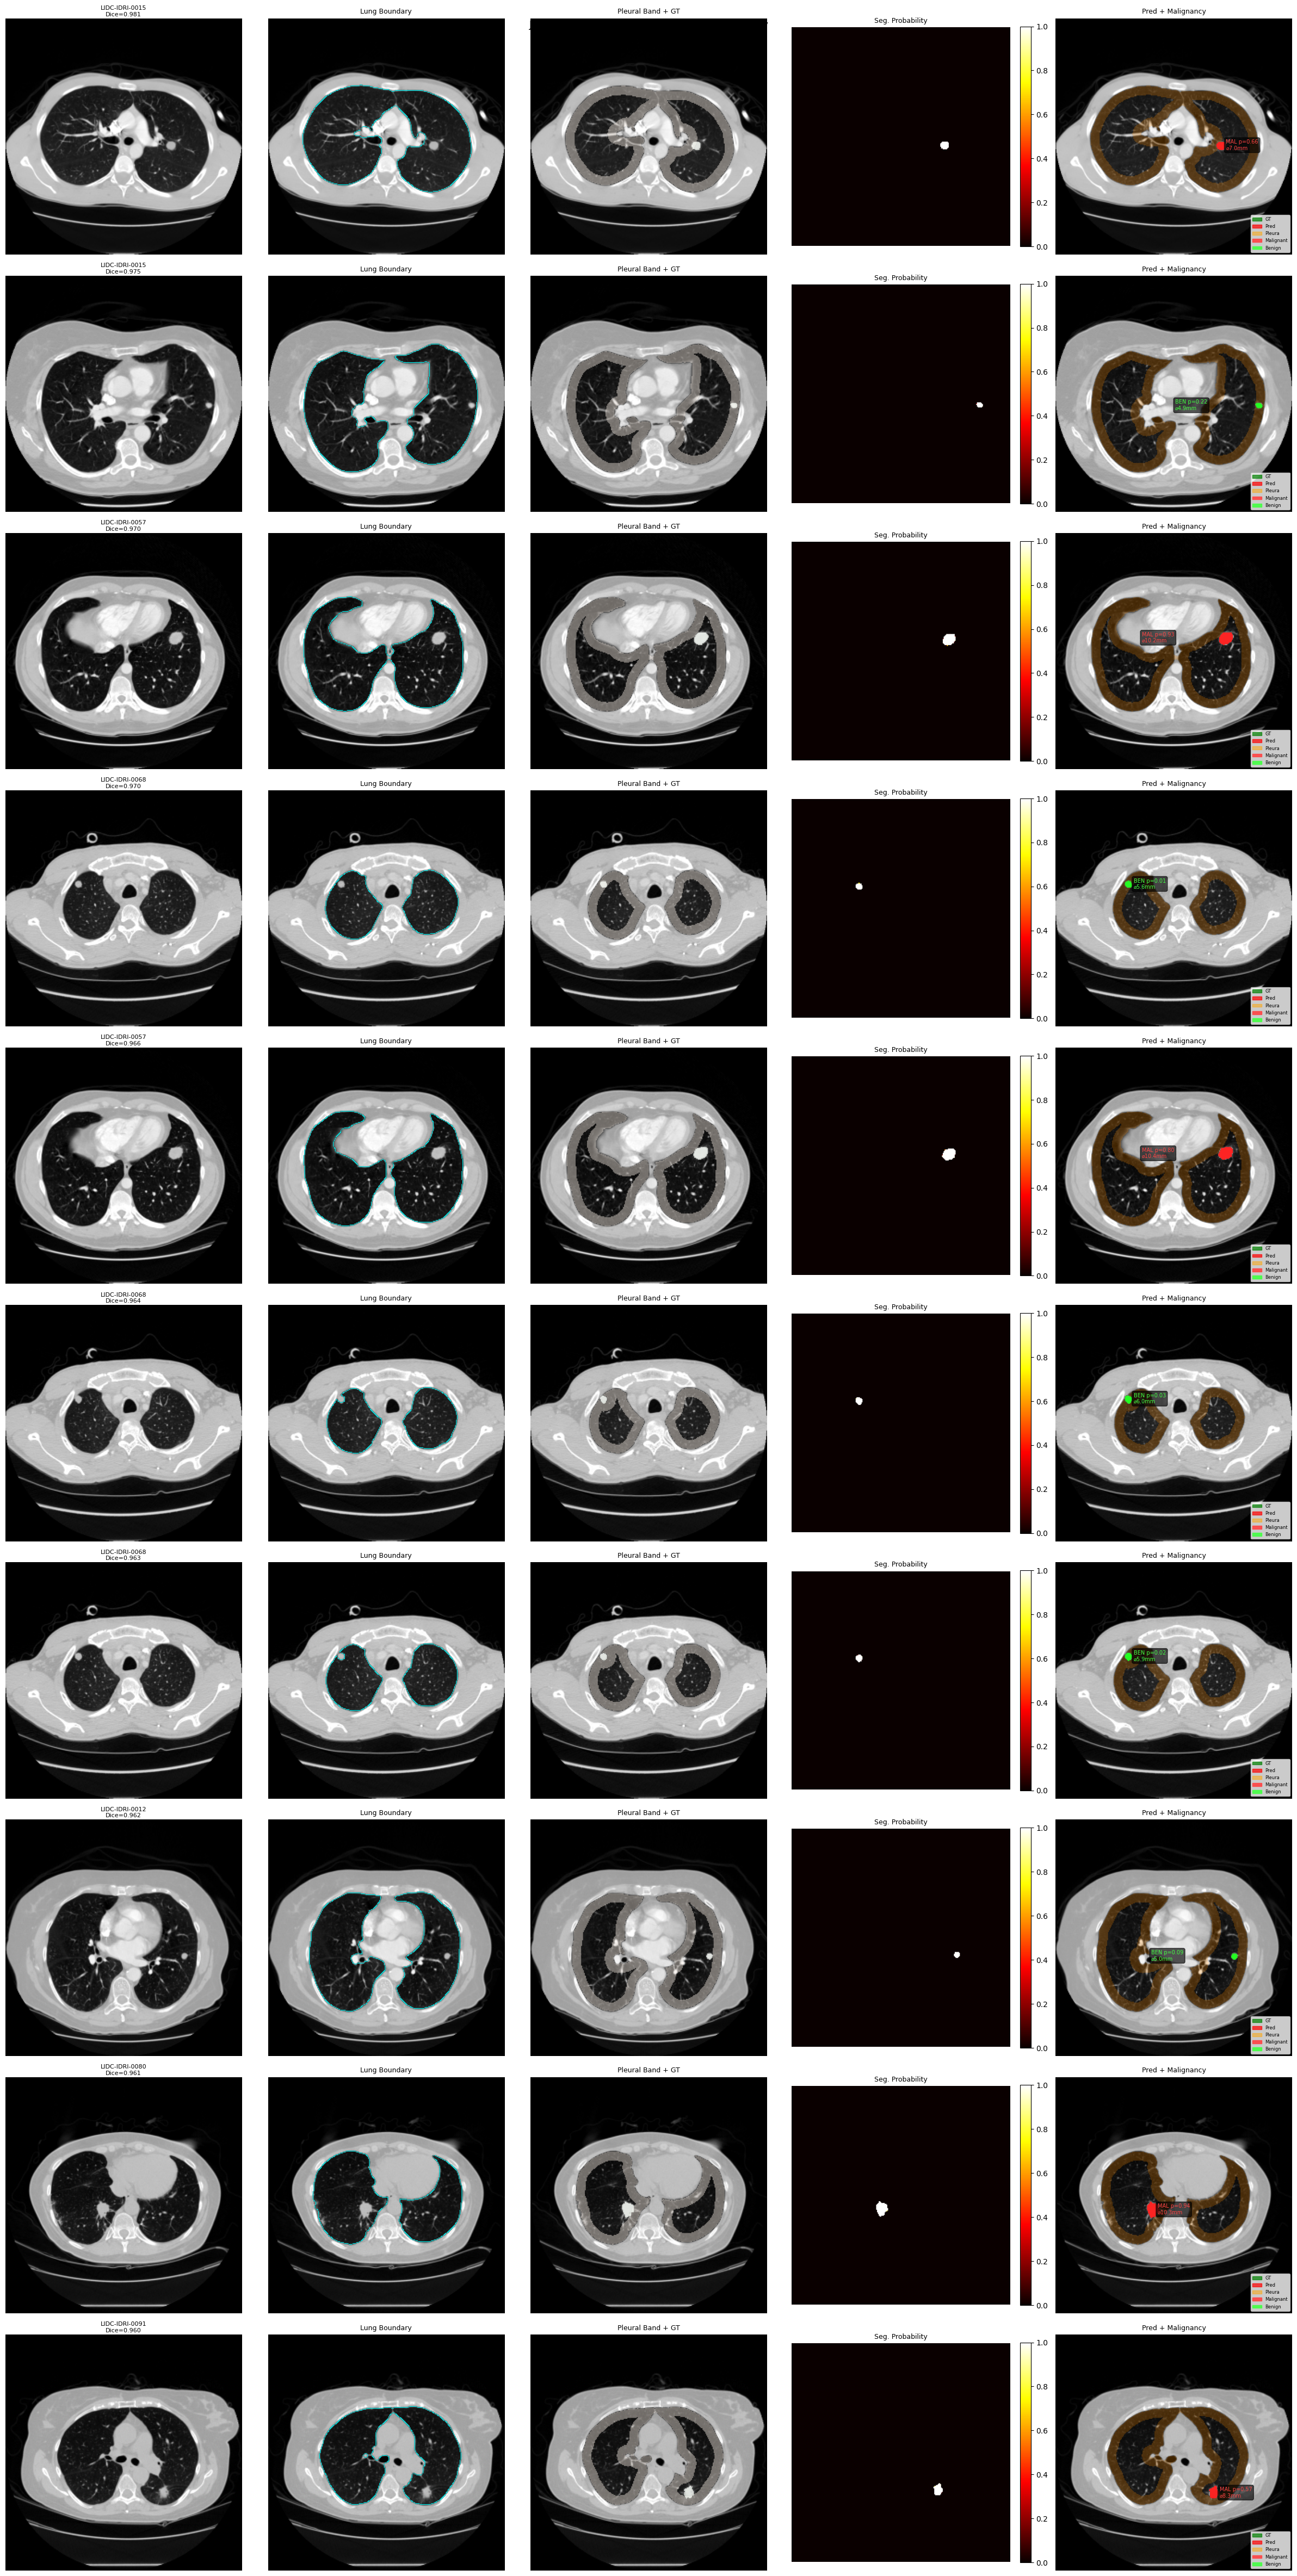


  JUXTA-PLEURAL + MALIGNANCY SUMMARY
  GT juxta-pleural slices  : 100
  Detected (Dice ≥ 0.10)   : 89
  Recall                   : 89.0%
  Malignant                : 52
  Benign                   : 41
  Malignancy rate          : 55.9%


In [23]:
# ══════════════════════════════════════════════════════════════════
#  STEP 9 — Juxta-pleural + Malignancy  (patient ID only, no slice#)
#  Run AFTER val_patient_ids_v2.py
# ══════════════════════════════════════════════════════════════════

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Build val_patient_ids — run this before Step 9
val_patient_ids = []

for pid in val_pids:
    for img, mask in by_patient.get(pid, []):
        if mask.sum() >= MIN_NODULE_PX:
            val_patient_ids.append(pid)

# Pad for randomly-kept empty slices (they won't appear in juxta results)
while len(val_patient_ids) < len(val_ds):
    val_patient_ids.append('EMPTY_SLICE')

val_patient_ids = val_patient_ids[:len(val_ds)]

print(f'val_patient_ids: {len(val_patient_ids)} entries')
print(f'Unique patients: {len(set(val_patient_ids) - {"EMPTY_SLICE"})}')
print(f'First 5: {val_patient_ids[:5]}')

NODULE_CROP_SIZE = 64
MAL_CKPT         = 'best_malignancy_classifier.pth'
JUXTA_DIST_PX    = 10

class MalignancyClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        import torchvision.models as tv_models
        from torchvision.models import ResNet18_Weights
        backbone = tv_models.resnet18(weights=None)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )
        self.net = backbone
    def forward(self, x):
        return self.net(x).squeeze(1)

mal_model = MalignancyClassifier().to(DEVICE)

# Now load the checkpoint
ckpt = torch.load(MAL_CKPT, map_location=DEVICE)
mal_model.load_state_dict(ckpt['model_state'])
mal_model.eval()
print(f"Malignancy classifier loaded  AUC={ckpt['val_auc']:.4f}")

ckpt = torch.load(MAL_CKPT, map_location=DEVICE)
mal_model.load_state_dict(ckpt['model_state'])
mal_model.eval()
print(f"Malignancy classifier loaded  AUC={ckpt['val_auc']:.4f}")


def classify_nodule_crop(img_norm, centroid_yx, crop_size=NODULE_CROP_SIZE):
    cy, cx = centroid_yx
    half   = crop_size // 2
    H, W   = img_norm.shape
    y1     = int(np.clip(cy - half, 0, H - crop_size))
    x1     = int(np.clip(cx - half, 0, W - crop_size))
    crop   = cv2.resize(img_norm[y1:y1+crop_size, x1:x1+crop_size],
                        (crop_size, crop_size))
    crop_t = torch.tensor(np.stack([crop]*3)[None],
                          dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logit = mal_model(crop_t)
    return float(torch.sigmoid(logit).cpu().item())


# ── Run malignancy on confirmed juxta-pleural slices ──────────────
print(f'Running malignancy on {len(confirmed_juxta)} juxta-pleural slices...')

jp_mal_results = []

for s in confirmed_juxta:
    idx       = s['idx']
    patient_id= s.get('patient_id', val_patient_ids[idx])
    img_t, _  = val_ds[idx]
    img_norm  = img_t[0].numpy()
    pred_mask = preds_bin[idx]
    gt_mask   = all_gts[idx]

    n_comp, comp_labels, stats, _ = cv2.connectedComponentsWithStats(
        pred_mask.astype(np.uint8), connectivity=8)

    nodules = []
    for cid in range(1, n_comp):
        area = stats[cid, cv2.CC_STAT_AREA]
        if area < 20:
            continue
        ys, xs = np.where(comp_labels == cid)
        cy, cx  = int(ys.mean()), int(xs.mean())

        # Coordinates in 256×256 space
        y_min, y_max = int(ys.min()), int(ys.max())
        x_min, x_max = int(xs.min()), int(xs.max())

        mal_prob = classify_nodule_crop(img_norm, (cy, cx))
        nodules.append({
            'centroid':    (cy, cx),
            'bbox':        (y_min, y_max, x_min, x_max),
            'area_px':     area,
            'diameter_mm': round(np.sqrt(4*area/np.pi) * 0.7, 1),
            'mal_prob':    round(mal_prob, 3),
            'mal_pred':    'Malignant' if mal_prob >= 0.5 else 'Benign',
        })

    jp_mal_results.append({
        'idx':        idx,
        'patient_id': patient_id,
        'dice':       s['dice'],
        'lung':       s['lung'],
        'pleura':     s['pleura'],
        'nodules':    nodules,
        'gt_mask':    gt_mask,
        'img_norm':   img_norm,
        'prob_map':   all_probs[idx],
    })

n_mal = sum(1 for r in jp_mal_results
            for n in r['nodules'] if n['mal_pred'] == 'Malignant')
n_ben = sum(1 for r in jp_mal_results
            for n in r['nodules'] if n['mal_pred'] == 'Benign')

# ── Console table ─────────────────────────────────────────────────
print('\n' + '─'*85)
print(f'{"IDX":>5}  {"PATIENT_ID":<22}  '
      f'{"CENTROID(r,c)":>13}  {"BBOX(r,c)":>22}  '
      f'{"⌀mm":>5}  {"MAL_P":>6}  {"PRED":>10}  {"DICE":>6}')
print('─'*85)

show_rows = sorted(
    [r for r in jp_mal_results if r['nodules'] and r['dice'] >= 0.1],
    key=lambda x: -x['dice']
)

for r in show_rows:
    for n in r['nodules']:
        cy, cx       = n['centroid']
        ym,yM,xm,xM = n['bbox']
        print(f'{r["idx"]:>5}  {r["patient_id"]:<22}  '
              f'({cy:>3},{cx:>3})          '
              f'r[{ym:>3}:{yM:>3}]c[{xm:>3}:{xM:>3}]  '
              f'{n["diameter_mm"]:>5}  '
              f'{n["mal_prob"]:>6.3f}  '
              f'{n["mal_pred"]:>10}  '
              f'{r["dice"]:>6.3f}')

print('─'*85)
print(f'Note: coordinates are in 256×256 prediction space.')

# ── Visualization ─────────────────────────────────────────────────
show_vis = show_rows[:10]

if show_vis:
    fig, axes = plt.subplots(len(show_vis), 5,
                             figsize=(24, 4.8 * len(show_vis)))
    if len(show_vis) == 1:
        axes = [axes]

    for row, r in enumerate(show_vis):
        idx      = r['idx']
        img_norm = r['img_norm']
        gt_mask  = r['gt_mask']
        pred_mask= preds_bin[idx]
        prob_map = r['prob_map']
        lung     = r['lung']
        pleura   = r['pleura']
        nodules  = r['nodules']

        # Panel 0: CT + patient ID
        axes[row][0].imshow(img_norm, cmap='gray')
        axes[row][0].set_title(
            f'{r["patient_id"]}\nDice={r["dice"]:.3f}',
            fontsize=8, pad=3)

        # Panel 1: lung boundary
        axes[row][1].imshow(img_norm, cmap='gray')
        edge = cv2.Canny((lung*255).astype(np.uint8), 100, 200)
        axes[row][1].imshow(
            np.ma.masked_where(edge == 0, edge.astype(float)),
            cmap='cool', alpha=0.9)
        axes[row][1].set_title('Lung Boundary', fontsize=9)

        # Panel 2: pleural band + GT
        axes[row][2].imshow(img_norm, cmap='gray')
        axes[row][2].imshow(
            np.ma.masked_where(pleura == 0, pleura.astype(float)),
            cmap='Oranges', alpha=0.42)
        if gt_mask.sum() > 0:
            axes[row][2].imshow(
                np.ma.masked_where(gt_mask == 0, gt_mask.astype(float)),
                cmap='Greens', alpha=0.65)
        axes[row][2].set_title('Pleural Band + GT', fontsize=9)

        # Panel 3: probability map
        im = axes[row][3].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
        axes[row][3].set_title('Seg. Probability', fontsize=9)
        plt.colorbar(im, ax=axes[row][3], fraction=0.046, pad=0.04)

        # Panel 4: pred + malignancy labels
        axes[row][4].imshow(img_norm, cmap='gray')
        pl_rgba = np.zeros((*img_norm.shape, 4), dtype=np.float32)
        pl_rgba[pleura > 0] = [1.0, 0.55, 0.0, 0.25]
        axes[row][4].imshow(pl_rgba)
        if gt_mask.sum() > 0:
            axes[row][4].imshow(
                np.ma.masked_where(gt_mask == 0, gt_mask.astype(float)),
                cmap='Greens', alpha=0.55)
        if pred_mask.sum() > 0:
            axes[row][4].imshow(
                np.ma.masked_where(pred_mask == 0, pred_mask.astype(float)),
                cmap='Reds', alpha=0.60)

        for n in nodules:
            cy, cx       = n['centroid']
            ym,yM,xm,xM = n['bbox']
            is_mal       = n['mal_pred'] == 'Malignant'
        
            # Build a colored mask just for this nodule component
            comp_mask = np.zeros((*img_norm.shape, 4), dtype=np.float32)
            # isolate this component by bbox + centroid proximity
            region = pred_mask[ym:yM+1, xm:xM+1]
            if is_mal:
                comp_mask[ym:yM+1, xm:xM+1, 0] = region   # R
                comp_mask[ym:yM+1, xm:xM+1, 3] = region * 0.85  # alpha
            else:
                comp_mask[ym:yM+1, xm:xM+1, 1] = region   # G
                comp_mask[ym:yM+1, xm:xM+1, 3] = region * 0.85
        
            axes[row][4].imshow(comp_mask, zorder=4)
        
            # Label text only (no dot)
            x_text = cx + 6 if cx < 180 else cx - 90
            dot_col = '#ff4444' if is_mal else '#44ff44'
            axes[row][4].text(
                x_text, cy,
                f"{'MAL' if is_mal else 'BEN'} p={n['mal_prob']:.2f}\n"
                f"⌀{n['diameter_mm']}mm",
                color=dot_col, fontsize=7, zorder=6,
                verticalalignment='center',
                bbox=dict(facecolor='black', alpha=0.65,
                          boxstyle='round,pad=0.3'))

        gt_p  = mpatches.Patch(color='green',   alpha=0.7, label='GT')
        pr_p  = mpatches.Patch(color='red',     alpha=0.7, label='Pred')
        pl_p  = mpatches.Patch(color='orange',  alpha=0.5, label='Pleura')
        mal_p = mpatches.Patch(color='#ff4444', alpha=0.9, label='Malignant')
        ben_p = mpatches.Patch(color='#44ff44', alpha=0.9, label='Benign')
        axes[row][4].legend(handles=[gt_p, pr_p, pl_p, mal_p, ben_p],
                            loc='lower right', fontsize=6)
        axes[row][4].set_title('Pred + Malignancy', fontsize=9)

        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle(
        f'Juxta-Pleural Nodules — Segmentation + Malignancy\n'
        f'{n_mal} Malignant  |  {n_ben} Benign  |  '
        f'Recall {len([r for r in jp_mal_results if r["dice"]>=0.1])}'
        f'/{len(jp_mal_results)}',
        fontsize=12)
    plt.tight_layout()
    plt.show()

# ── Summary ───────────────────────────────────────────────────────
print('\n' + '='*50)
print('  JUXTA-PLEURAL + MALIGNANCY SUMMARY')
print('='*50)
detected = [r for r in jp_mal_results if r['dice'] >= 0.1]
print(f'  GT juxta-pleural slices  : {len(jp_mal_results)}')
print(f'  Detected (Dice ≥ 0.10)   : {len(detected)}')
print(f'  Recall                   : {len(detected)/max(len(jp_mal_results),1):.1%}')
print(f'  Malignant                : {n_mal}')
print(f'  Benign                   : {n_ben}')
if n_mal + n_ben > 0:
    print(f'  Malignancy rate          : {n_mal/(n_mal+n_ben):.1%}')
print('='*50)

       LUNG NODULE SEGMENTATION — SUMMARY
  Model          : ResUNet-34 (pretrained ResNet34)
  Checkpoint     : best_resunet34_v3.pth
  Best threshold : 0.10
  Mean Dice (all): 0.6306
  Mean Dice (+)  : 0.6336
  Positive slices: 176 / 180
  Juxta-pleural  : 102 predicted / 131 GT
  Nodule diam    : 6.8 mm avg


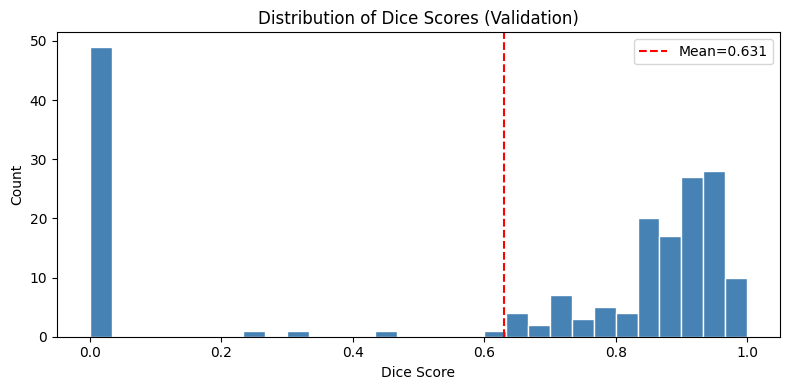

In [22]:
print('=' * 55)
print('       LUNG NODULE SEGMENTATION — SUMMARY')
print('=' * 55)
print(f'  Model          : ResUNet-34 (pretrained ResNet34)')
print(f'  Checkpoint     : {CKPT_PATH}')
print(f'  Best threshold : {BEST_THRESHOLD:.2f}')
print(f'  Mean Dice (all): {mean_dice:.4f}')
print(f'  Mean Dice (+)  : {pos_dice:.4f}')
print(f'  Positive slices: {len(pos_idx)} / {len(all_gts)}')
print(f'  Juxta-pleural  : {juxta_pred_count} predicted / {juxta_gt_count} GT')
if nodule_stats:mal
    print(f'  Nodule diam    : {np.mean(diameters):.1f} mm avg')
print('=' * 55)

# Histogram of Dice scores
plt.figure(figsize=(8, 4))
plt.hist(dice_list, bins=30, color='steelblue', edgecolor='white')
plt.axvline(mean_dice, color='r', linestyle='--', label=f'Mean={mean_dice:.3f}')
plt.xlabel('Dice Score'); plt.ylabel('Count')
plt.title('Distribution of Dice Scores (Validation)')
plt.legend(); plt.tight_layout(); plt.show()

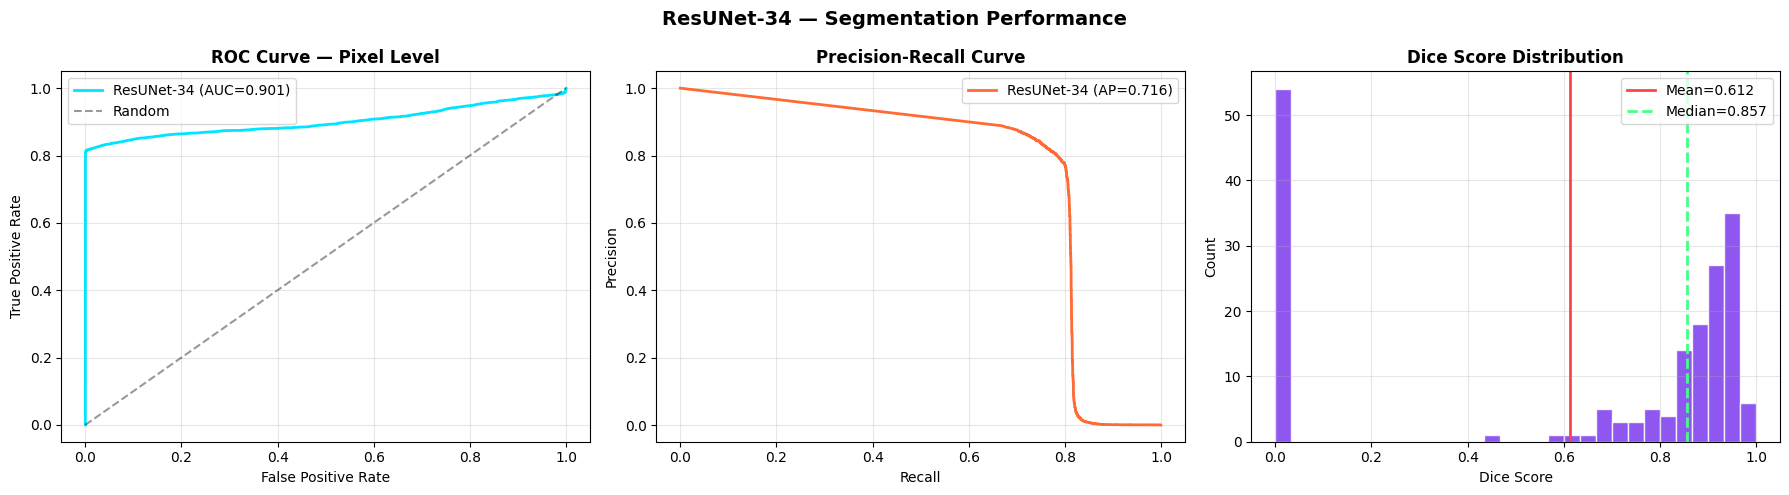

In [26]:
# ── ROC + Precision-Recall curves ────────────────────────────────
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

flat_probs = all_probs.flatten()
flat_gts   = all_gts.flatten().astype(int)
idx = np.random.choice(len(flat_probs), 5_000_000, replace=False)
fp_s = flat_probs[idx]; gt_s = flat_gts[idx]

fpr, tpr, _ = roc_curve(gt_s, fp_s)
auc_val      = roc_auc_score(gt_s, fp_s)
prec, rec, _ = precision_recall_curve(gt_s, fp_s)
ap           = average_precision_score(gt_s, fp_s)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
axes[0].plot(fpr, tpr, color='#00e5ff', lw=2, label=f'ResUNet-34 (AUC={auc_val:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Pixel Level', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Precision-Recall
axes[1].plot(rec, prec, color='#ff6b35', lw=2, label=f'ResUNet-34 (AP={ap:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Dice distribution
pos_dices = [dice_list[i] for i in range(len(all_gts)) if all_gts[i].sum() > 0]
axes[2].hist(pos_dices, bins=30, color='#7c3aed', edgecolor='white', alpha=0.85)
axes[2].axvline(np.mean(pos_dices), color='#ff4444', lw=2,
                label=f'Mean={np.mean(pos_dices):.3f}')
axes[2].axvline(np.median(pos_dices), color='#44ff88', lw=2, linestyle='--',
                label=f'Median={np.median(pos_dices):.3f}')
axes[2].set_xlabel('Dice Score'); axes[2].set_ylabel('Count')
axes[2].set_title('Dice Score Distribution', fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('ResUNet-34 — Segmentation Performance', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()